In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, ticker
import freqcol_0_6 as fc

import msise2Netcdf as msise
import irinetcdf_02 as iri
import pyigrf_clara_0_6 as igrf

import conductivity0_9_5 as cond

### Declaring Functions

#### Relative Parameter

In [4]:
def calc_pRelativa(rhoi,ne):
    """
    Calcula a densidade numérica relativa da espécie ionica. Brekke (1993).
    
    Parameters
    ----------
    rhoi : PANDA SERIES FLOAT
        densidade do íon [m^-3]     
    ne : PANDA SERIES FLOAT
        Densidade de elétrons [elétrons/m^3]
    
    Returns:
    ----------
    pi : PANDA SERIES FLOAT
        densidade numérica relativa (Brekke,1983)
        
    """    
    pi = rhoi/ne        
    return pi


#### Hall

In [257]:
def calc_Hall(fen,fin1,fin2,wi1,wi2,we,p1,p2,ne,B,save=True,name="_"):
        """
        CALCULA A CONDUTIVIDADE DE HALL APARTIR DAS EQUAÇÕES DE Adachi et al.
        Earth, Planets and Space (2017).

        Parameters
        ----------
        fen : PANDA SERIES
            frequência de colisão dos elétrons com as partículas neutras [Hz].
        fin1 : PANDA SERIES
            frequência de colisão do íon 1 com as partículas neutras [Hz].
        fin2 : PANDA SERIES
            frequência de colisão do íon 2 com as partículas neutras [Hz].
        wi1 : PANDA SERIES
            girofrequência do íon 1 [Hz].
        wi2 : PANDA SERIES
            girofrequência do íon 2 [Hz].
        we : PANDA SERIES
            girofrequência do elétron [Hz].
        p1 : TYPE
            DESCRIPTION.
        p2 : TYPE
            DESCRIPTION.
        ne : TYPE
            densidade de elétrons em [m^-3].
        B : TYPE
            intensidade do campo magnético da Terra [T].

        Returns
        -------
        self.condH : TYPE
            DESCRIPTION.

        """         
        print("\nCalculando a Condutividade de Hall...")
        e = -1.602177e-19 #Carga do elétron [C]
        d = 0
        soma = 0
        
        a1 = wi2**2/(wi2**2 + fin2**2)
        b1 = (wi1**2)/(wi1**2 + fin1**2)
        c1 = (we**2)/(we**2 + fen**2)

        soma = c1 - (p1 * b1) - (p2 * a1)
        d = (ne * e)/B

        CondH  = d * soma
        print("CondH type",type(CondH))
    
        if save:
            CondH.dropna().to_csv("Hall_Conductivity"+name+'.csv')
            print("File: "+"Hall_Conductivity"+name+"saved")
            
        print("Done")
        #return soma
        return CondH

#### Pedersen

In [8]:
def calc_Pedersen(fen,fin1,fin2,wi1,wi2,we,p1,p2,ne,B):
        """
        CALCULA A CONDUTIVIDADE DE PEDERSEN APARTIR DAS EQUAÇÕES DE Adachi et al.
        Earth, Planets and Space (2017).

        Parameters
        ----------
        fen : PANDA SERIES
            frequência de colisão dos elétrons com as partículas neutras [Hz].
        fin1 : PANDA SERIES
            frequência de colisão do íon 1 com as partículas neutras [Hz].
        fin2 : PANDA SERIES
            frequência de colisão do íon O+ com as partículas neutras [Hz].
        wi1 : PANDA SERIES
            girofrequencia do íon 1 [Hz].
        wi2 : TYPE
            girofrequência do íon O+ [Hz].
        we : TYPE
            DESCRIPTION.
        p1 : TYPE
            DESCRIPTION.
        p2 : TYPE
            DESCRIPTION.
        ne : TYPE
            DESCRIPTION.
        B : TYPE
            DESCRIPTION.

        Returns
        -------
        self.CondP : TYPE
            DESCRIPTION.

        """
        e = -1.602177e-19 #Carga do elétron [C]
        d = 0
        soma = 0
        
        print("===== Calculando a condutividade de Pedersen =====")
        
        a1 = (wi2 * fin2)/(wi2**2 + fin2**2)
        b1 = (wi1 * fin1)/(wi1**2 + fin1**2)
        c1 = (we * fen)/(we**2 + fen**2)
            
        soma = c1 + p1*b1 + p2*a1
        d = (ne * np.sqrt(e**2))/B
        
        CondP = d * soma
        
        print('Done')
        #return CondP
        return CondP

## Constants

In [10]:
me = 9.109389e-31 #Massa do elétron em repouso [kg]
e = -1.602177e-19 #Carga do elétron [C]
mi1 = 5.065e-26 #Massa do íon 1 uma mistura de NO+ (75%) e O2+ (25%) (30.5 u.m.a.) [kg]
mi2 = 2.657e-26 #Massa do íon 2 (O+) [kg] (16 a.m.u)

In [11]:
time = '0 days 1:00:00'

In [12]:
#help(fc.freqcol)

## Program Start

### Reading data

#### IRI

In [16]:
namefileiri = "IRI.3D.2008001.nc"
iriteste = iri.irincdf(namefileiri)

In [17]:
iriteste.iridata.data.columns.to_list()

['Ne', 'Tn', 'Ti', 'Te', 'O+', 'H+', 'He+', 'O2+', 'NO+', 'N+']

In [18]:
iriteste.iridata.munit['H+'] #getting information on a variable

{'long_name': 'Atomic_Hydrogen_ion_density', 'units': '/m^3'}

In [19]:
iriteste.iridata.data["O+"] #getting the data from the variable

time             ht      lat    lon  
0 days 00:00:00  100.0   -90.0  0.0              0.0
                                5.0              0.0
                                10.0             0.0
                                15.0             0.0
                                20.0             0.0
                                            ...     
0 days 23:45:00  1000.0   90.0  340.0    778916800.0
                                345.0    778917184.0
                                350.0    778917184.0
                                355.0    778917184.0
                                360.0    778916416.0
Name: O+, Length: 11927616, dtype: float32

#### IRI 2D

In [21]:
namefileiri = "IRI.2D.2008001.nc"
iriteste2 = iri.irincdf(namefileiri)

In [22]:
O  = iriteste.iridata.data["O+"].loc[time]
NO = iriteste.iridata.data["NO+"].loc[time]
ne = iriteste.iridata.data["Ne"].loc[time]
O2 = iriteste.iridata.data["O2+"].loc[time]

N  = iriteste.iridata.data["N+"].loc[time]
H  = iriteste.iridata.data["H+"].loc[time]
He = iriteste.iridata.data["He+"].loc[time]

In [23]:
#O.loc[140,-50]/ne.loc[140,-50]

In [24]:
iriteste.iridata.munit

{'Ne': {'long_name': 'Electron_density', 'units': '/m**3'},
 'Tn': {'long_name': 'Neutral_Temperature', 'units': 'K'},
 'Ti': {'long_name': 'Ion_Temperature', 'units': 'K'},
 'Te': {'long_name': 'Electron_Temperature', 'units': 'K'},
 'O+': {'long_name': 'Atomic_Oxygen_ion_density', 'units': '/m^3'},
 'H+': {'long_name': 'Atomic_Hydrogen_ion_density', 'units': '/m^3'},
 'He+': {'long_name': 'Atomic_Helium_ion_density', 'units': '/m^3'},
 'O2+': {'long_name': 'Molecular_Oxygen_ion_density', 'units': '/m^3'},
 'NO+': {'long_name': 'Nitric_Oxide_ion_density', 'units': '/m^3'},
 'N+': {'long_name': 'Atomic_Nitrogen_ion_density', 'units': '/m^3'}}

In [25]:
iriteste2.iridata.munit

{'TEC': {'long_name': 'TEC', 'units': 'TECU'},
 'NmF2': {'long_name': 'NmF2', 'units': '/m^3'},
 'HmF2': {'long_name': 'HmF2', 'units': 'km'}}

In [26]:
O.index.get_level_values('lon').unique()

Index([  0.0,   5.0,  10.0,  15.0,  20.0,  25.0,  30.0,  35.0,  40.0,  45.0,
        50.0,  55.0,  60.0,  65.0,  70.0,  75.0,  80.0,  85.0,  90.0,  95.0,
       100.0, 105.0, 110.0, 115.0, 120.0, 125.0, 130.0, 135.0, 140.0, 145.0,
       150.0, 155.0, 160.0, 165.0, 170.0, 175.0, 180.0, 185.0, 190.0, 195.0,
       200.0, 205.0, 210.0, 215.0, 220.0, 225.0, 230.0, 235.0, 240.0, 245.0,
       250.0, 255.0, 260.0, 265.0, 270.0, 275.0, 280.0, 285.0, 290.0, 295.0,
       300.0, 305.0, 310.0, 315.0, 320.0, 325.0, 330.0, 335.0, 340.0, 345.0,
       350.0, 355.0, 360.0],
      dtype='float32', name='lon')

##### Plotting Iri Data

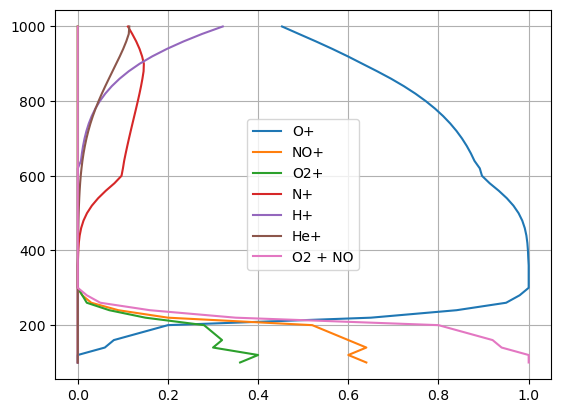

In [28]:
#O.loc[:,-50,60]/ne.loc[:,-50,60],NO.loc[:,-50,60]/ne.loc[:,-50,60],O2.loc[:,-50,60]/ne.loc[:,-50,60]

#composição da atmosfera
lon1 = 150

plt.plot(O.loc[:,-50,lon1]/ne.loc[:,-50,lon1],O.index.get_level_values('ht').unique(),label='O+')
plt.plot(NO.loc[:,-50,lon1]/ne.loc[:,-50,lon1],NO.index.get_level_values('ht').unique(),label='NO+')
plt.plot(O2.loc[:,-50,lon1]/ne.loc[:,-50,lon1],O2.index.get_level_values('ht').unique(),label='O2+')
plt.plot(N.loc[:,-50,lon1]/ne.loc[:,-50,lon1],O2.index.get_level_values('ht').unique(),label='N+')

plt.plot(H.loc[:,-50,lon1]/ne.loc[:,-50,lon1],H.index.get_level_values('ht').unique(),label='H+')
plt.plot(He.loc[:,-50,lon1]/ne.loc[:,-50,lon1],He.index.get_level_values('ht').unique(),label='He+')

plt.plot((O2.loc[:,-50,lon1] + NO.loc[:,-50,lon1])/ne.loc[:,-50,lon1], O2.index.get_level_values('ht').unique(), label='O2 + NO')

plt.legend()
plt.grid()

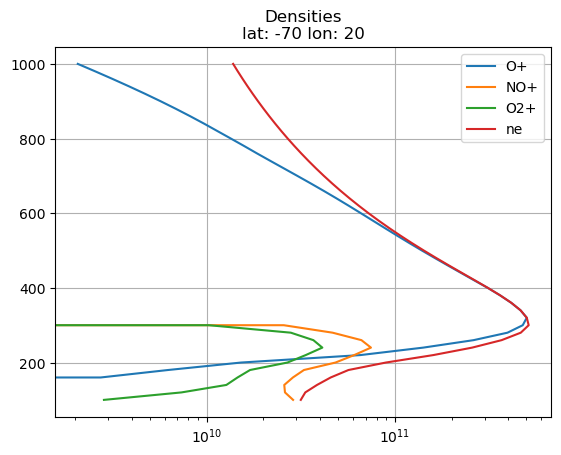

In [29]:
#O.loc[:,-50,60]/ne.loc[:,-50,60],NO.loc[:,-50,60]/ne.loc[:,-50,60],O2.loc[:,-50,60]/ne.loc[:,-50,60]

#composição da atmosfera
lon1 = 20
lat1 = -70

plt.title("Densities\nlat: " + str(lat1) + " lon: "+str(lon1))
plt.semilogx(O.loc[:,lat1,lon1],O.index.get_level_values('ht').unique(),label='O+')
plt.plot(NO.loc[:,lat1,lon1],NO.index.get_level_values('ht').unique(),label='NO+')
plt.plot(O2.loc[:,lat1,lon1],O2.index.get_level_values('ht').unique(),label='O2+')
#plt.plot(N.loc[:,lat1,lon1],O2.index.get_level_values('ht').unique(),label='N+')

#plt.plot(H.loc[:,lat1,lon1],H.index.get_level_values('ht').unique(),label='H+')
#plt.plot(He.loc[:,lat1,lon1],He.index.get_level_values('ht').unique(),label='He+')

#plt.plot((O2.loc[:,lat1,lon1] + NO.loc[:,lat1,lon1]), O2.index.get_level_values('ht').unique(), label='O2 + NO')
plt.plot(ne.loc[:,lat1,lon1],ne.index.get_level_values('ht').unique(),label='ne')

plt.legend()
plt.grid()

#### IGRF

In [31]:
resIGRF = "teste2024"
dado = igrf.IGRF(-80,-180,100,2008,resIGRF + '_2') #preciso garantir que estão nas mesmas coordenadas

#calcigrf = dado.calc_grid(intervalo_h = 20, lim_h = 500, intervalo_lat=10, lim_lat=90, intervalo_lon=20, lim_lon=180) #calculating grid
calcigrf = dado.get_grid(resIGRF + '_2' + "_grid.csv") #reading the results

# print(calcigrf["B(T)"],
#       calcigrf["Altitude"],
#       calcigrf["Latitude"],
#       calcigrf["Longitude"])

dado.Dfgrid['Longitude'] = 180 + dado.Dfgrid['Longitude'] #so it will be from 0 to 360 instead
dado.Dfgrid = dado.going_to_multiindex(dado.Dfgrid)
dado.Dfgrid.index.names = ['ht','lat','lon'] #putting the same index names as the rest of the data to allow join operations

print("\nFeito\n"),calcigrf


Feito



(None,
       Unnamed: 0  Altitude  Latitude  Longitude    Year  Declination  \
 0              0     100.0     -80.0        0.0  2008.0   130.650016   
 20            20     100.0     -80.0       20.0  2008.0   106.832854   
 40            40     100.0     -80.0       40.0  2008.0    87.026928   
 60            60     100.0     -80.0       60.0  2008.0    69.730176   
 80            80     100.0     -80.0       80.0  2008.0    53.741100   
 ...          ...       ...       ...        ...     ...          ...   
 6039        6039     480.0      80.0      260.0  2008.0    26.928769   
 6059        6059     480.0      80.0      280.0  2008.0    17.599779   
 6079        6079     480.0      80.0      300.0  2008.0     2.255246   
 6099        6099     480.0      80.0      320.0  2008.0    -3.066547   
 6119        6119     480.0      80.0      340.0  2008.0     1.817205   
 
       Inclination  Horizontal_intensity  Total_intensity  North_component  \
 0      -78.987166          11153.322

#### Msise

In [33]:
filenamemsise2 = "NRLMSIS2.0.3D.2008001.nc"
msisetest = msise.nrlmsisenetcdf(filenamemsise2)

In [34]:
msisetest.msise.data

O            N2            O2  \
time            ht    lat   lon                                               
0 days 00:00:00 0.0   -90.0 0.0    9.999000e-32  1.210602e+25  3.246318e+24   
                            20.0   9.999000e-32  1.210602e+25  3.246318e+24   
                            40.0   9.999000e-32  1.210602e+25  3.246318e+24   
                            60.0   9.999000e-32  1.210602e+25  3.246318e+24   
                            80.0   9.999000e-32  1.210602e+25  3.246318e+24   
...                                         ...           ...           ...   
0 days 23:45:00 500.0  90.0 280.0  1.001533e+12  1.627130e+09  2.226342e+07   
                            300.0  1.001533e+12  1.627130e+09  2.226342e+07   
                            320.0  1.001533e+12  1.627130e+09  2.226342e+07   
                            340.0  1.001533e+12  1.627130e+09  2.226342e+07   
                            360.0  1.001533e+12  1.627130e+09  2.226342e+07   

                                           MASS          NT          ET  \
time            ht    lat   lon                                           
0 days 00:00:00 0.0   -90.0 0.0    7.452317e+02  235.886612  884.880249   
                            20.0   7.452317e+02  235.886612  884.880249   
                            40.0   7.452317e+02  235.886612  884.880249   
                            60.0   7.452317e+02  235.886612  884.880249   
                            80.0   7.452317e+02  235.886612  884.880249   
...                                         ...         ...         ...   
0 days 23:45:00 500.0  90.0 280.0  5.771498e-11  662.652161  662.652161   
                            300.0  5.771498e-11  662.652161  662.652161   
                            320.0  5.771498e-11  662.652161  662.652161   
                            340.0  5.771498e-11  662.652161  662.652161   
                            360.0  5.771498e-11  662.652161  662.652161   

                                             He            AR            AO  \
time            ht    lat   lon                                               
0 days 00:00:00 0.0   -90.0 0.0    8.061927e+19  1.446806e+23  9.999000e-32   
                            20.0   8.061927e+19  1.446806e+23  9.999000e-32   
                            40.0   8.061927e+19  1.446806e+23  9.999000e-32   
                            60.0   8.061927e+19  1.446806e+23  9.999000e-32   
                            80.0   8.061927e+19  1.446806e+23  9.999000e-32   
...                                         ...           ...           ...   
0 days 23:45:00 500.0  90.0 280.0  4.539662e+12  3.420119e+03  2.482889e+09   
                            300.0  4.539662e+12  3.420119e+03  2.482889e+09   
                            320.0  4.539662e+12  3.420119e+03  2.482889e+09   
                            340.0  4.539662e+12  3.420119e+03  2.482889e+09   
                            360.0  4.539662e+12  3.420119e+03  2.482889e+09   

                                              H             N  
time            ht    lat   lon                                
0 days 00:00:00 0.0   -90.0 0.0    9.999000e-32  9.999000e-32  
                            20.0   9.999000e-32  9.999000e-32  
                            40.0   9.999000e-32  9.999000e-32  
                            60.0   9.999000e-32  9.999000e-32  
                            80.0   9.999000e-32  9.999000e-32  
...                                         ...           ...  
0 days 23:45:00 500.0  90.0 280.0  3.050579e+11  1.307304e+10  
                            300.0  3.050579e+11  1.307304e+10  
                            320.0  3.050579e+11  1.307304e+10  
                            340.0  3.050579e+11  1.307304e+10  
                            360.0  3.050579e+11  1.307304e+10  

[6816288 rows x 11 columns]

In [35]:
msisetest.msise.munit

{'O': {'long_name': 'O_Number_Density', 'units': 'CM-3 * 1e6'},
 'N2': {'long_name': 'N2_Number_Density', 'units': 'CM-3 * 1e6'},
 'O2': {'long_name': 'O2_Number_Density', 'units': 'CM-3 * 1e6'},
 'MASS': {'long_name': 'Total_Mass_Density', 'units': 'GM/CM3 * 1e6'},
 'NT': {'long_name': 'Temperature_at_Alt', 'units': 'K'},
 'ET': {'long_name': 'Exospheric_Temperature', 'units': 'K'},
 'He': {'long_name': 'He_Number_Density', 'units': 'CM-3 * 1e6'},
 'AR': {'long_name': 'Ar_Number_Density', 'units': 'CM-3 * 1e6'},
 'AO': {'long_name': 'Anomalous_Oxygen_Number_Density', 'units': 'CM-3 * 1e6'},
 'H': {'long_name': 'H_Number_Density', 'units': 'CM-3 * 1e6'},
 'N': {'long_name': 'N_Number_Density', 'units': 'CM-3 * 1e6'}}

In [36]:
#msisetest.msise['O'].data.loc[time,:,-50,60]
#msisetest.msise['NO'].data.loc['0 days 00:00:00',:,-50,60]

## Starting Calculations

### Calculating Colision Frequency

In [39]:
freqc = fc.freqcol(msisetest.msise.data["N2"].loc[time],
            msisetest.msise.data["O2"].loc[time],
            msisetest.msise.data["O"].loc[time],
            iriteste.iridata.data['Te'].loc[time],
            iriteste.iridata.data['Tn'].loc[time],
            iriteste.iridata.data['Ti'].loc[time])


Calculating Collision Frequency...
Done


In [40]:
freqc.result.dropna()

fen         fin1         fin2
ht    lat   lon                                          
100.0 -90.0 0.0    10120.293065  1105.479115  1754.183149
            20.0   10120.293065  1105.479115  1754.183149
            40.0   10120.293065  1105.479115  1754.183149
            60.0   10120.293065  1105.479115  1754.183149
            80.0   10120.293065  1105.479115  1754.183149
...                         ...          ...          ...
500.0  90.0 280.0      0.000071     0.000242     0.000805
            300.0      0.000071     0.000242     0.000805
            320.0      0.000071     0.000242     0.000805
            340.0      0.000071     0.000242     0.000805
            360.0      0.000071     0.000242     0.000805

[14763 rows x 3 columns]

### Calculating relative contruibution parammeter

In [42]:
#-relative contribution parameters
parelO = calc_pRelativa(iriteste.iridata.data["O+"], iriteste.iridata.data["Ne"])
parel1 = calc_pRelativa((iriteste.iridata.data["NO+"] + iriteste.iridata.data["O2+"])/2, iriteste.iridata.data["Ne"])

In [43]:
print(parelO,"\n\n",parel1)

time             ht      lat    lon  
0 days 00:00:00  100.0   -90.0  0.0      0.000000
                                5.0      0.000000
                                10.0     0.000000
                                15.0     0.000000
                                20.0     0.000000
                                           ...   
0 days 23:45:00  1000.0   90.0  340.0    0.086636
                                345.0    0.086636
                                350.0    0.086636
                                355.0    0.086636
                                360.0    0.086636
Length: 11927616, dtype: float32 

 time             ht      lat    lon  
0 days 00:00:00  100.0   -90.0  0.0      0.5
                                5.0      0.5
                                10.0     0.5
                                15.0     0.5
                                20.0     0.5
                                        ... 
0 days 23:45:00  1000.0   90.0  340.0    0.0
                       

#### Ploting relative contribution parameter

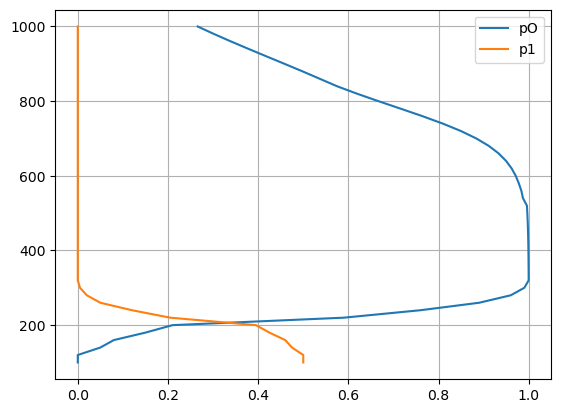

In [45]:
plt.plot(parelO.loc[time,:,-80,80],parelO.index.get_level_values('ht').unique(),label='pO')
plt.plot(parel1.loc[time,:,-80,80],parel1.index.get_level_values('ht').unique(),label='p1')
plt.legend()
plt.grid()

### Calculationg Gyrofrequency

In [47]:
gyrofreq = cond.gyrofrequency(dado.Dfgrid["B(T)"])
gyrofreq.result.index.names = ['ht','lat',"lon"] #renaming index levels

calculando as freqcol all: start 
Done


In [48]:
gyrofreq.result

we         wi1         wi2
ht    lat   lon                                        
100.0 -80.0 0.0    1.026896e+07  184.686988  352.066087
            20.0   1.005710e+07  180.876687  344.802566
            40.0   9.754655e+06  175.437217  334.433385
            60.0   9.388836e+06  168.857966  321.891455
            80.0   8.992655e+06  161.732656  308.308583
...                         ...         ...         ...
480.0  80.0 260.0  8.273699e+06  148.802251  283.659542
            280.0  8.341833e+06  150.027639  285.995481
            300.0  8.360026e+06  150.354847  286.619232
            320.0  8.336816e+06  149.937420  285.823498
            340.0  8.297310e+06  149.226893  284.469029

[6120 rows x 3 columns]

In [49]:
#Joining in a single data frame in order to facilitate the calculations  
calcvaluesdf = gyrofreq.result.join(freqc.result.copy(),
                          how = 'inner') #inner para ficarem só as coordenadas que ambos dataframes tem

calcvaluesdf

we         wi1         wi2           fen  \
ht    lat   lon                                                         
100.0 -80.0 0.0    1.026896e+07  184.686988  352.066087  10663.768855   
            20.0   1.005710e+07  180.876687  344.802566  10542.710644   
            40.0   9.754655e+06  175.437217  334.433385  10365.767093   
            60.0   9.388836e+06  168.857966  321.891455  10177.917962   
            80.0   8.992655e+06  161.732656  308.308583  10033.780739   
...                         ...         ...         ...           ...   
480.0  80.0 260.0  8.273699e+06  148.802251  283.659542      0.000262   
            280.0  8.341833e+06  150.027639  285.995481      0.000250   
            300.0  8.360026e+06  150.354847  286.619232      0.000166   
            320.0  8.336816e+06  149.937420  285.823498      0.000159   
            340.0  8.297310e+06  149.226893  284.469029      0.000153   

                          fin1         fin2  
ht    lat   lon                              
100.0 -80.0 0.0    1153.247628  1830.102061  
            20.0   1141.931286  1812.121940  
            40.0   1130.313404  1793.604065  
            60.0   1119.370611  1776.143301  
            80.0   1110.524800  1762.041203  
...                        ...          ...  
480.0  80.0 260.0     0.000481     0.001542  
            280.0     0.000462     0.001464  
            300.0     0.000441     0.001399  
            320.0     0.000424     0.001351  
            340.0     0.000409     0.001308  

[6120 rows x 6 columns]

### Calculating the Conductivities

In [51]:
conductivity = cond.condiono_adachi()

In [52]:
#calculating relative parameters
p1,pO = conductivity.calc_prelativa_all(iriteste.iridata.data["O+"].loc[time],
                        iriteste.iridata.data["NO+"].loc[time],
                        iriteste.iridata.data["O2+"].loc[time],
                        iriteste.iridata.data["Ne"].loc[time])

Calculating relative contribution parameters...
Done


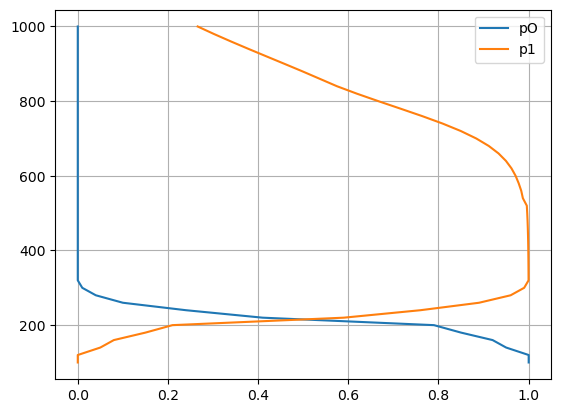

In [53]:
plt.plot(pO.loc[:,-80,80],pO.index.get_level_values('ht').unique(),label='pO')
plt.plot(p1.loc[:,-80,80],p1.index.get_level_values('ht').unique(),label='p1')
plt.legend()
plt.grid()

In [54]:
#1.602177e-19 * (iriteste.iridata.data["Ne"].loc[time]/dado.Dfgrid["B(T)"]).dropna()

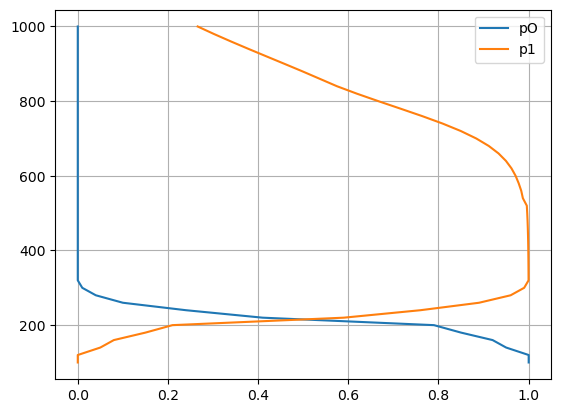

In [55]:
plt.plot(pO.loc[:,-80,80],pO.index.get_level_values('ht').unique(),label='pO')
plt.plot(p1.loc[:,-80,80],p1.index.get_level_values('ht').unique(),label='p1')
plt.legend()
plt.grid()

#### Alinging Data

In [57]:
#Alining Data by putting everything in a same Data Frame
conductivity.calcvaluesdf = gyrofreq.result.join(freqc.result.copy(),
                          how = 'inner') #inner para ficarem só as coordenadas que ambos dataframes tem

#= Ordered multiindex
conductivity.calcvaluesdf 

we         wi1         wi2           fen  \
ht    lat   lon                                                         
100.0 -80.0 0.0    1.026896e+07  184.686988  352.066087  10663.768855   
            20.0   1.005710e+07  180.876687  344.802566  10542.710644   
            40.0   9.754655e+06  175.437217  334.433385  10365.767093   
            60.0   9.388836e+06  168.857966  321.891455  10177.917962   
            80.0   8.992655e+06  161.732656  308.308583  10033.780739   
...                         ...         ...         ...           ...   
480.0  80.0 260.0  8.273699e+06  148.802251  283.659542      0.000262   
            280.0  8.341833e+06  150.027639  285.995481      0.000250   
            300.0  8.360026e+06  150.354847  286.619232      0.000166   
            320.0  8.336816e+06  149.937420  285.823498      0.000159   
            340.0  8.297310e+06  149.226893  284.469029      0.000153   

                          fin1         fin2  
ht    lat   lon                              
100.0 -80.0 0.0    1153.247628  1830.102061  
            20.0   1141.931286  1812.121940  
            40.0   1130.313404  1793.604065  
            60.0   1119.370611  1776.143301  
            80.0   1110.524800  1762.041203  
...                        ...          ...  
480.0  80.0 260.0     0.000481     0.001542  
            280.0     0.000462     0.001464  
            300.0     0.000441     0.001399  
            320.0     0.000424     0.001351  
            340.0     0.000409     0.001308  

[6120 rows x 6 columns]

#### Hall

In [59]:
# Hall - using condiono library
conductivity.calc_Hall(conductivity.calcvaluesdf["fen"],
                       conductivity.calcvaluesdf["fin1"],
                       conductivity.calcvaluesdf["fin2"], 
                       conductivity.calcvaluesdf['wi1'],
                       conductivity.calcvaluesdf['wi2'],
                       conductivity.calcvaluesdf['we'],
                       conductivity.p1,
                       conductivity.p2,
                       iriteste.iridata.data['Ne'].loc[time],
                       dado.Dfgrid["B(T)"]).dropna()


== Calculando a Condutividade de Hall
Done


ht     lat    lon  
100.0  -80.0  0.0      0.000116
              20.0     0.000124
              40.0     0.000137
              60.0     0.000154
              80.0     0.000173
                         ...   
480.0   80.0  260.0    0.000019
              280.0    0.000021
              300.0    0.000023
              320.0    0.000026
              340.0    0.000027
Length: 6120, dtype: float64

In [60]:
conductivity.CondH.rename("Hall's conductivity [S/m]").dropna()

ht     lat    lon  
100.0  -80.0  0.0      0.000116
              20.0     0.000124
              40.0     0.000137
              60.0     0.000154
              80.0     0.000173
                         ...   
480.0   80.0  260.0    0.000019
              280.0    0.000021
              300.0    0.000023
              320.0    0.000026
              340.0    0.000027
Name: Hall's conductivity [S/m], Length: 6120, dtype: float64

In [61]:
#Using function defined in this code
testehall = calc_Hall(calcvaluesdf["fen"],
                       calcvaluesdf["fin1"],
                       calcvaluesdf["fin2"], 
                       calcvaluesdf['wi1'],
                       calcvaluesdf['wi2'],
                       calcvaluesdf['we'],
                       parelO.loc[time],
                       parel1.loc[time],
                       iriteste.iridata.data['Ne'].loc[time],
                       dado.Dfgrid["B(T)"],True,"wetrqerewrt").dropna()
testehall


Calculando a Condutividade de Hall...
CondH type <class 'pandas.core.series.Series'>
File: Hall_Conductivitywetrqerewrtsaved
Done


ht     lat    lon  
100.0  -80.0  0.0      0.000118
              20.0     0.000126
              40.0     0.000139
              60.0     0.000156
              80.0     0.000175
                         ...   
480.0   80.0  260.0    0.000019
              280.0    0.000021
              300.0    0.000023
              320.0    0.000026
              340.0    0.000027
Length: 6120, dtype: float64

In [62]:
#saving results 
testehall.to_csv("teste_condH")

#### Pedersen

In [64]:
#Pedersen - using condiono library
conductivity.calc_Pedersen(conductivity.calcvaluesdf["fen"],
                       conductivity.calcvaluesdf["fin1"],
                       conductivity.calcvaluesdf["fin2"], 
                       conductivity.calcvaluesdf['wi1'],
                       conductivity.calcvaluesdf['wi2'],
                       conductivity.calcvaluesdf['we'],
                       conductivity.p1,
                       conductivity.p2,
                       iriteste.iridata.data['Ne'].loc[time],
                       dado.Dfgrid["B(T)"]).dropna()
conductivity.CondP.rename("Pedersen's conductivity [S/m]")


== Calculando a condutividade de Pedersen
Done



ht      lat    lon  
100.0   -90.0  0.0     NaN
               5.0     NaN
               10.0    NaN
               15.0    NaN
               20.0    NaN
                        ..
1000.0   90.0  340.0   NaN
               345.0   NaN
               350.0   NaN
               355.0   NaN
               360.0   NaN
Name: Pedersen's conductivity [S/m], Length: 124246, dtype: float64

In [65]:

conductivity.calc_Pedersen(calcvaluesdf["fen"],
                       calcvaluesdf["fin1"],
                       calcvaluesdf["fin2"], 
                       calcvaluesdf['wi1'],
                       calcvaluesdf['wi2'],
                       calcvaluesdf['we'],
                       parelO.loc[time],
                       parel1.loc[time],
                       iriteste.iridata.data['Ne'].loc[time],
                       dado.Dfgrid["B(T)"]).dropna()


== Calculando a condutividade de Pedersen
Done



ht     lat    lon  
100.0  -80.0  0.0      1.123564e-05
              20.0     1.188992e-05
              40.0     1.289356e-05
              60.0     1.408370e-05
              80.0     1.529081e-05
                           ...     
480.0   80.0  260.0    8.727134e-10
              280.0    7.840557e-10
              300.0    7.336458e-10
              320.0    7.096089e-10
              340.0    6.879577e-10
Length: 6120, dtype: float64

In [66]:

#pedersen using function defined in this code
testepedersen = calc_Pedersen(calcvaluesdf["fen"],
                      calcvaluesdf["fin1"],
                      calcvaluesdf["fin2"], 
                      calcvaluesdf['wi1'],
                      calcvaluesdf['wi2'],
                      calcvaluesdf['we'],
                      parelO.loc[time],
                      parel1.loc[time],
                      iriteste.iridata.data['Ne'].loc[time],
                      dado.Dfgrid["B(T)"]).dropna()
testepedersen

===== Calculando a condutividade de Pedersen =====
Done


ht     lat    lon  
100.0  -80.0  0.0      1.123564e-05
              20.0     1.188992e-05
              40.0     1.289356e-05
              60.0     1.408370e-05
              80.0     1.529081e-05
                           ...     
480.0   80.0  260.0    8.727134e-10
              280.0    7.840557e-10
              300.0    7.336458e-10
              320.0    7.096089e-10
              340.0    6.879577e-10
Length: 6120, dtype: float64

## Plotting

In [68]:
h = 200 #height to plot data in km

testepedersen_plot = testepedersen.loc[h].reset_index() #Returning to normal index so lat and long may be columns 
testehall_plot = testehall.loc[h].reset_index()
ne_plot = ne.loc[h].reset_index()

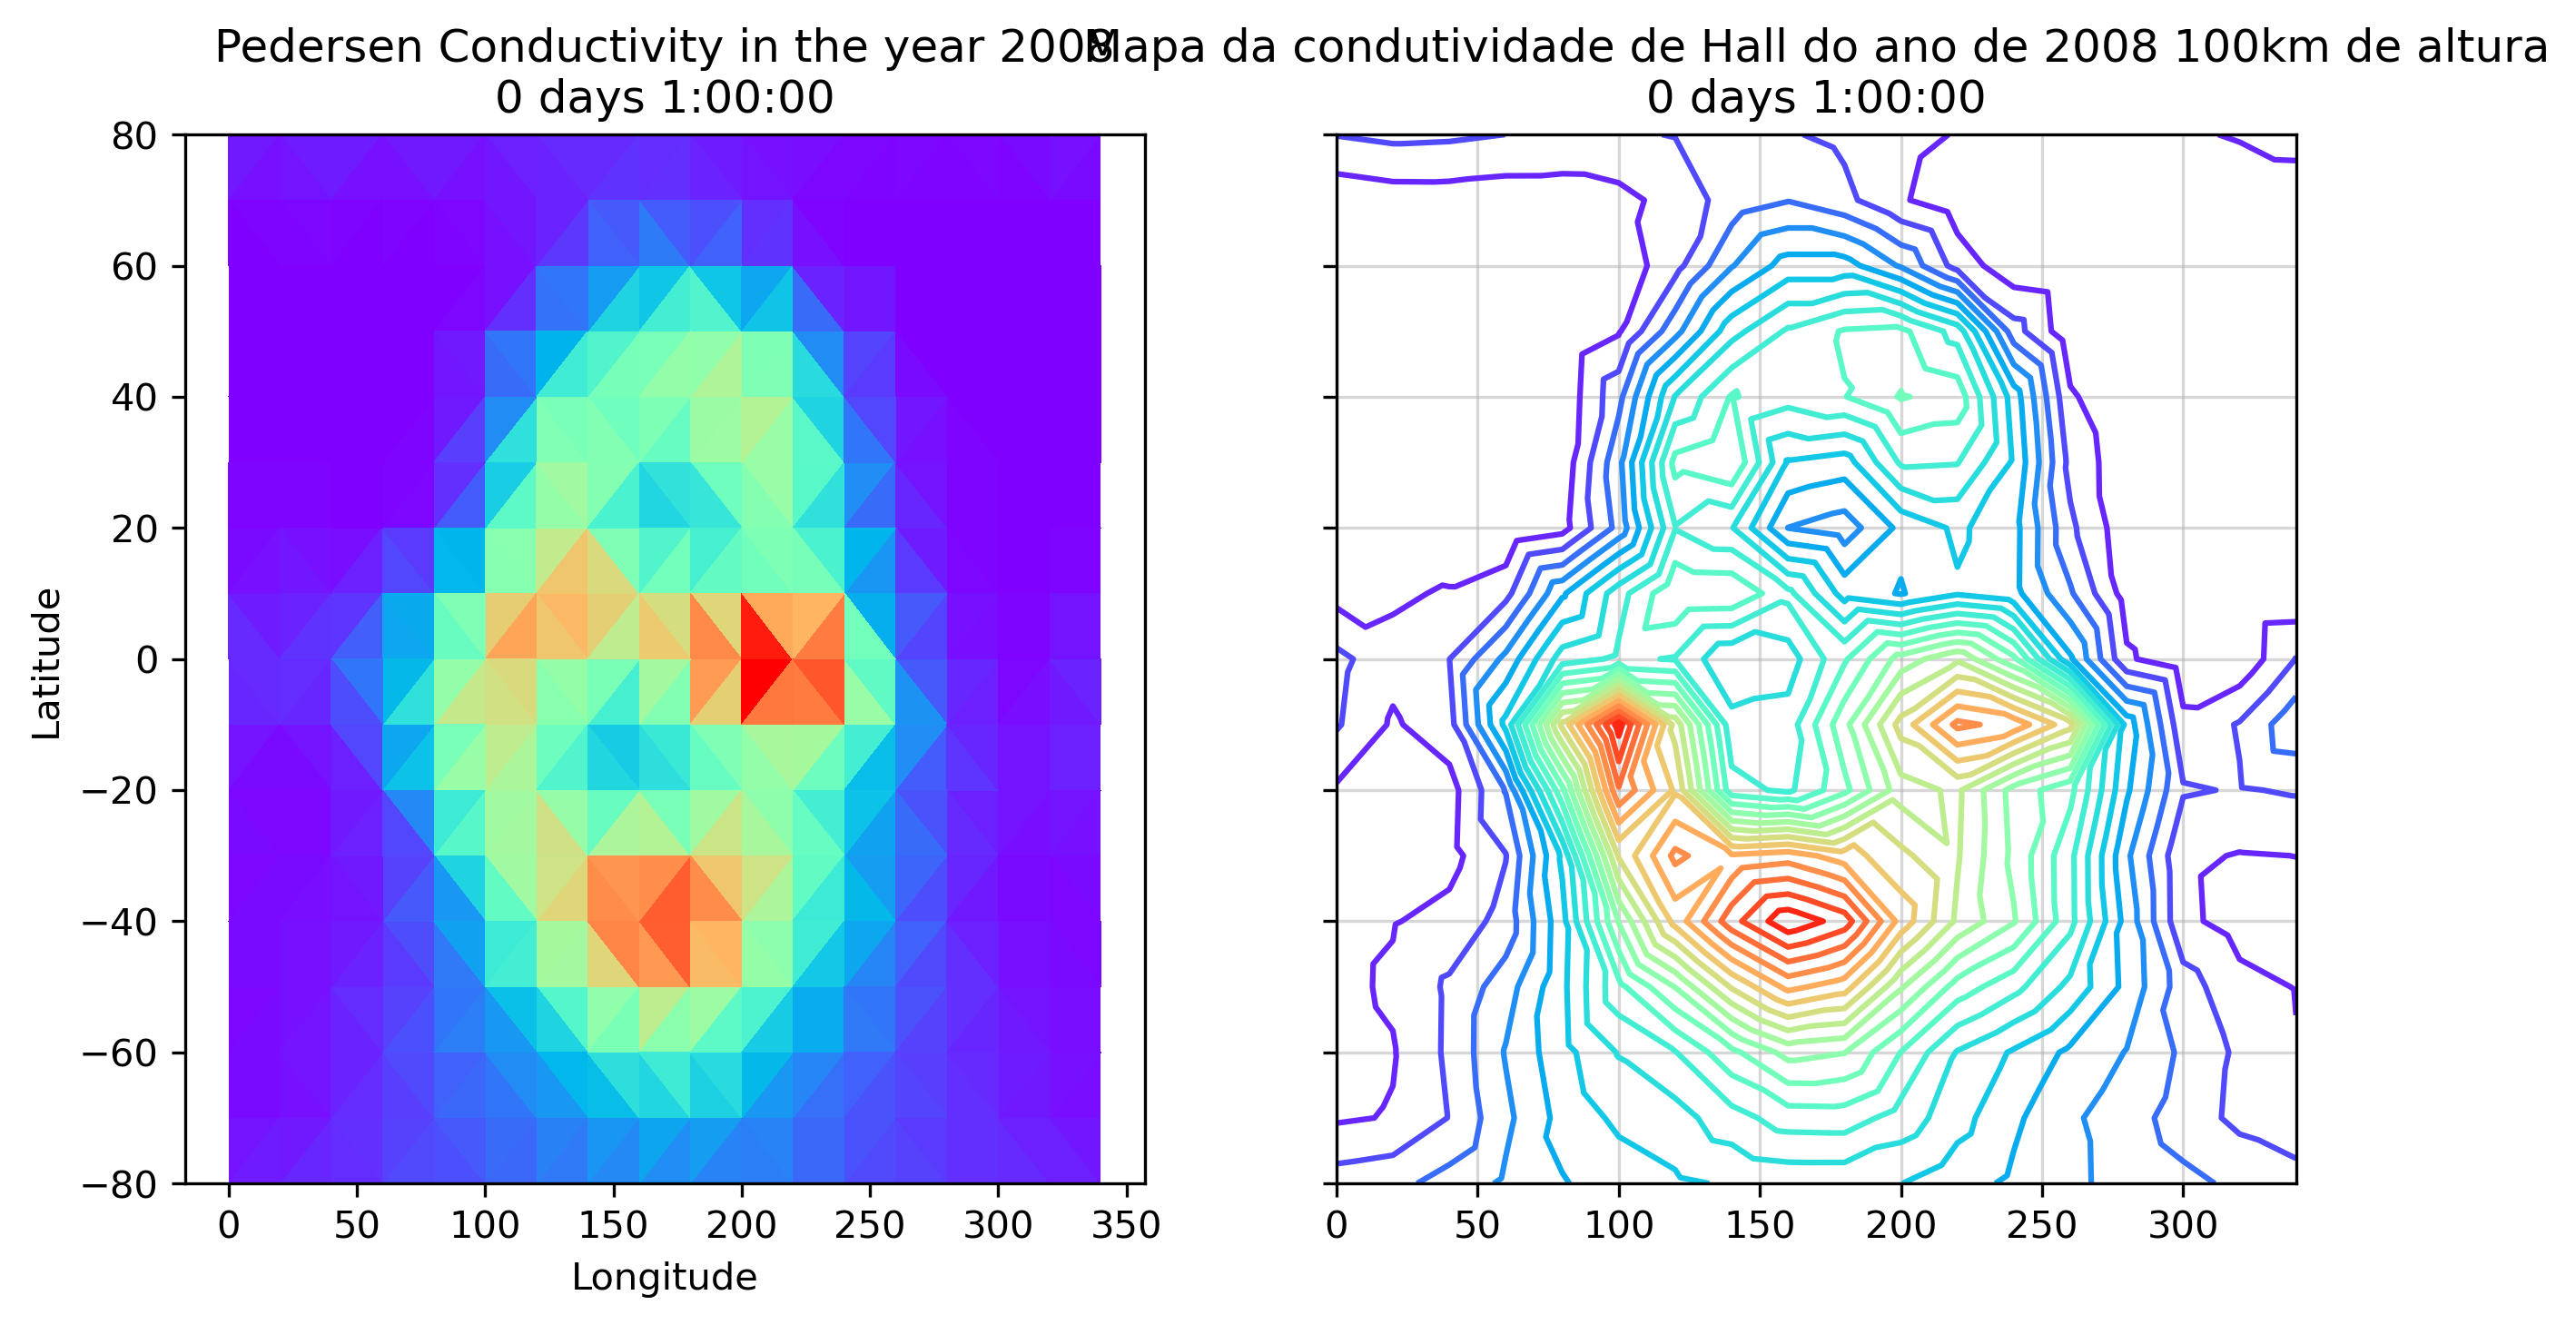

In [69]:
fig,ax = plt.subplots(1,2,figsize=(10,5),sharey=True,dpi=300)
ax[0].set_title("Pedersen Conductivity in the year 2008\n"+time)
ax[0].set_ylabel("Latitude")
ax[0].set_xlabel("Longitude")
#ax[0].legend()
#fig.colorbar()
ax[0].grid(visible = True, alpha=0.5)
#ax[0].tricontour(testepedersen_plot["lon"],testepedersen_plot["lat"],testepedersen_plot.loc[:,0],10,cmap='rainbow')

ax[1].tricontour(testehall_plot["lon"],testehall_plot["lat"],testehall_plot.loc[:,0],20,cmap='rainbow')
ax[1].grid(visible = True, alpha=0.5)
ax[1].set_title("Mapa da condutividade de Hall do ano de 2008 100km de altura\n"+time)

ax[0].tripcolor(testepedersen_plot["lon"],testepedersen_plot["lat"],testepedersen_plot.loc[:,0],cmap='rainbow')

### Grafico 2D

In [71]:
X,Y = np.meshgrid(testehall_plot["lon"].unique()-180,testehall_plot["lat"].unique())
Xe,Ye = np.meshgrid( ne_plot['lon'].unique()-180, ne_plot['lat'].unique())

In [72]:
X,Y,X[1,2]

(array([[-180., -160., -140., -120., -100.,  -80.,  -60.,  -40.,  -20.,
            0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.],
        [-180., -160., -140., -120., -100.,  -80.,  -60.,  -40.,  -20.,
            0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.],
        [-180., -160., -140., -120., -100.,  -80.,  -60.,  -40.,  -20.,
            0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.],
        [-180., -160., -140., -120., -100.,  -80.,  -60.,  -40.,  -20.,
            0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.],
        [-180., -160., -140., -120., -100.,  -80.,  -60.,  -40.,  -20.,
            0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.],
        [-180., -160., -140., -120., -100.,  -80.,  -60.,  -40.,  -20.,
            0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.],
        [-180., -160., -140., -120., -100.,  -80.,  -60.,  -40.,  -20.,
            0.,   20.,   40.,   60.,   80.,  100.,  120., 

#### Defining prepplot_2dgrid

In [74]:
def prepplot_2dgrid(values,h,title=" "):
    values_plot = values.loc[h].reset_index() #leaving the multindex to use normal indexing
    
    X,Y = np.meshgrid(values_plot['lon'].unique() - 180,values_plot['lat'].unique())

    value2dformat = pd.DataFrame([])
    for i in values_plot['lon'].unique():
        value2dformat[i] = values.loc[h,:,i]
        #print('\n\n i',i,'\nvalues2dformat[i]\n',value2dformat[i],'\n\n values.loc[]',values.loc[h,:,i])
        
    return X,Y,value2dformat

In [75]:
def prepplot_valueto2Dgrid(values,h):
    value2dformat = pd.DataFrame([])
    values_plot = values.loc[h].reset_index() #leaving the multindex to use normal indexing
    
    for i in values_plot['lon'].unique():
        value2dformat[i] = values.loc[h,:,i]
        #print('\n\n i',i,'\nvalues2dformat[i]\n',value2dformat[i],'\n\n values.loc[]',values.loc[h,:,i])
    
    return value2dformat

def prepplot_create2Dmeshgrid(values,h):
    values_plot = values.loc[h].reset_index() #leaving the multindex to use normal indexing
    
    X,Y = np.meshgrid(values_plot['lon'].unique() - 180, values_plot['lat'].unique())
    
    return X,Y

In [76]:
fen = freqc.result['fen'].dropna()
fen

ht     lat    lon  
100.0  -90.0  0.0      10120.293065
              20.0     10120.293065
              40.0     10120.293065
              60.0     10120.293065
              80.0     10120.293065
                           ...     
500.0   90.0  280.0        0.000071
              300.0        0.000071
              320.0        0.000071
              340.0        0.000071
              360.0        0.000071
Name: fen, Length: 14763, dtype: float64

#### plot_2dgrid

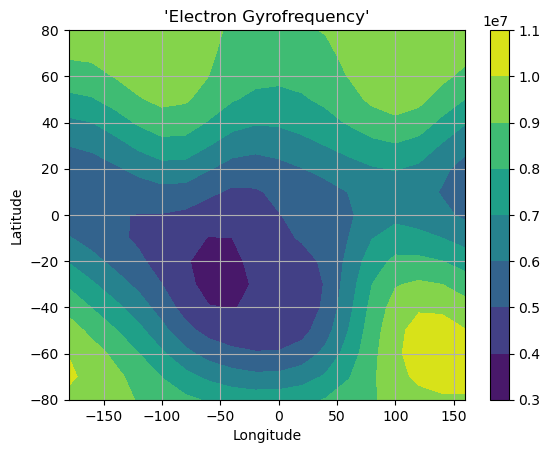

<module 'matplotlib.pyplot' from 'C:\\Users\\tedea\\Anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [78]:
def plot_2dgrid(values,h,title=" "):
    values_plot = values.loc[h].reset_index() #leaving the multindex to use normal indexing
    
    X,Y = np.meshgrid(values_plot['lon'].unique()-180,values_plot['lat'].unique())

    value2dformat = pd.DataFrame([])
    for i in values_plot['lon'].unique():
        value2dformat[i] = values.loc[h,:,i]
        
    plt.contourf(X,Y,value2dformat)
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid()
    plt.colorbar()   
    
    plt.show()
    return plt
    
plot_2dgrid(calcvaluesdf['we'],h,"'Electron Gyrofrequency'")

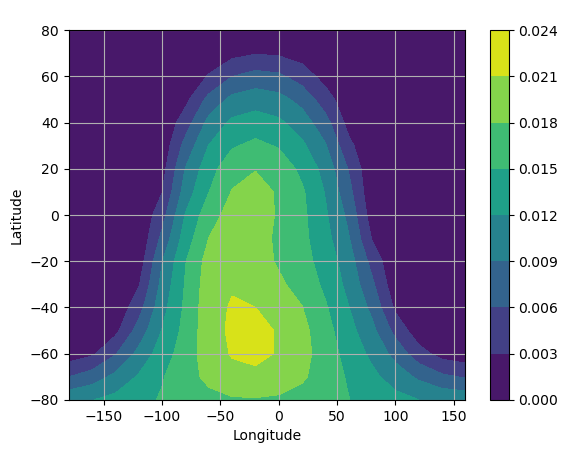

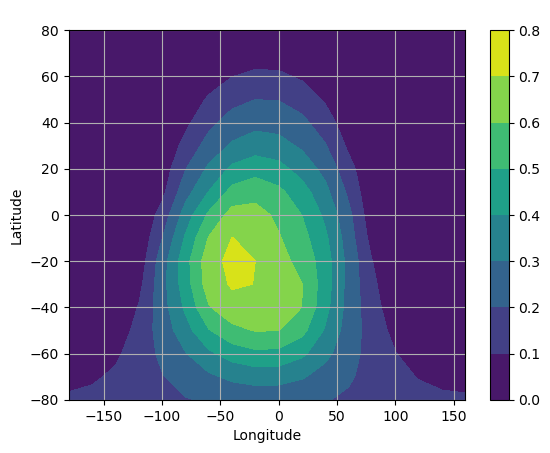

(<module 'matplotlib.pyplot' from 'C:\\Users\\tedea\\Anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>,
 <module 'matplotlib.pyplot' from 'C:\\Users\\tedea\\Anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>)

In [253]:
plot_2dgrid(testepedersen*1000,100),plot_2dgrid(testehall*1000,100)

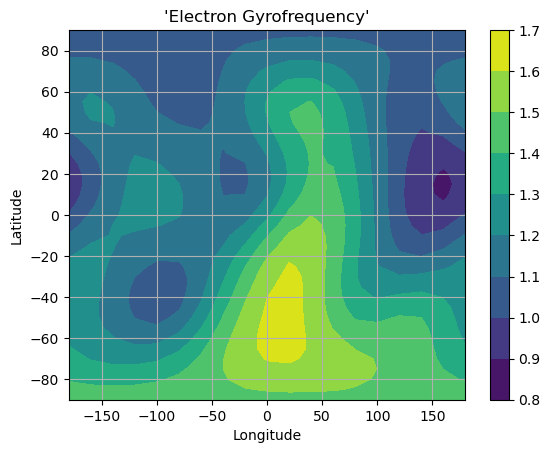

<module 'matplotlib.pyplot' from 'C:\\Users\\tedea\\Anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [80]:
plot_2dgrid(freqc.result['fin1'].dropna(),h,"'Electron Gyrofrequency'")

In [81]:
freqcres_plot = freqc.result['fin1'].loc[h].reset_index()
fin = freqc.result['fin1'].dropna().reset_index()
fin

,ht,lat,lon,fin1
0,0.0,-90.0,0.0,6.566674e+09
1,0.0,-90.0,20.0,6.566674e+09
2,0.0,-90.0,40.0,6.566674e+09
3,0.0,-90.0,60.0,6.566674e+09
4,0.0,-90.0,80.0,6.566674e+09
...,...,...,...,...
70998,500.0,90.0,280.0,2.420769e-04
70999,500.0,90.0,300.0,2.420769e-04
71000,500.0,90.0,320.0,2.420769e-04
71001,500.0,90.0,340.0,2.420769e-04


In [82]:
freqc.result['fin1'].loc[h]

lat    lon  
-90.0  0.0      1.466449
       5.0           NaN
       10.0          NaN
       15.0          NaN
       20.0     1.466449
                  ...   
 90.0  340.0    1.082349
       345.0         NaN
       350.0         NaN
       355.0         NaN
       360.0    1.082349
Name: fin1, Length: 2701, dtype: float64

In [83]:
freqcres_plot = freqc.result.loc[h].dropna().reset_index()

valuefen = pd.DataFrame([])
for i in freqcres_plot['lon'].dropna().unique():
    #print("\nlon",i,'\n',testepedersen.loc[100,:,i])
    valuefen[i] = freqc.result["fen"].loc[h,:,i]

In [84]:
Xfen,Yfen = np.meshgrid(ne_plot['lon'].unique()-180, ne_plot['lat'].unique())

#### Gyrofrequency

In [86]:
pip install pillow

In [87]:
import geopandas as gpd

In [88]:
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

countries = gpd.read_file(url)
#countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

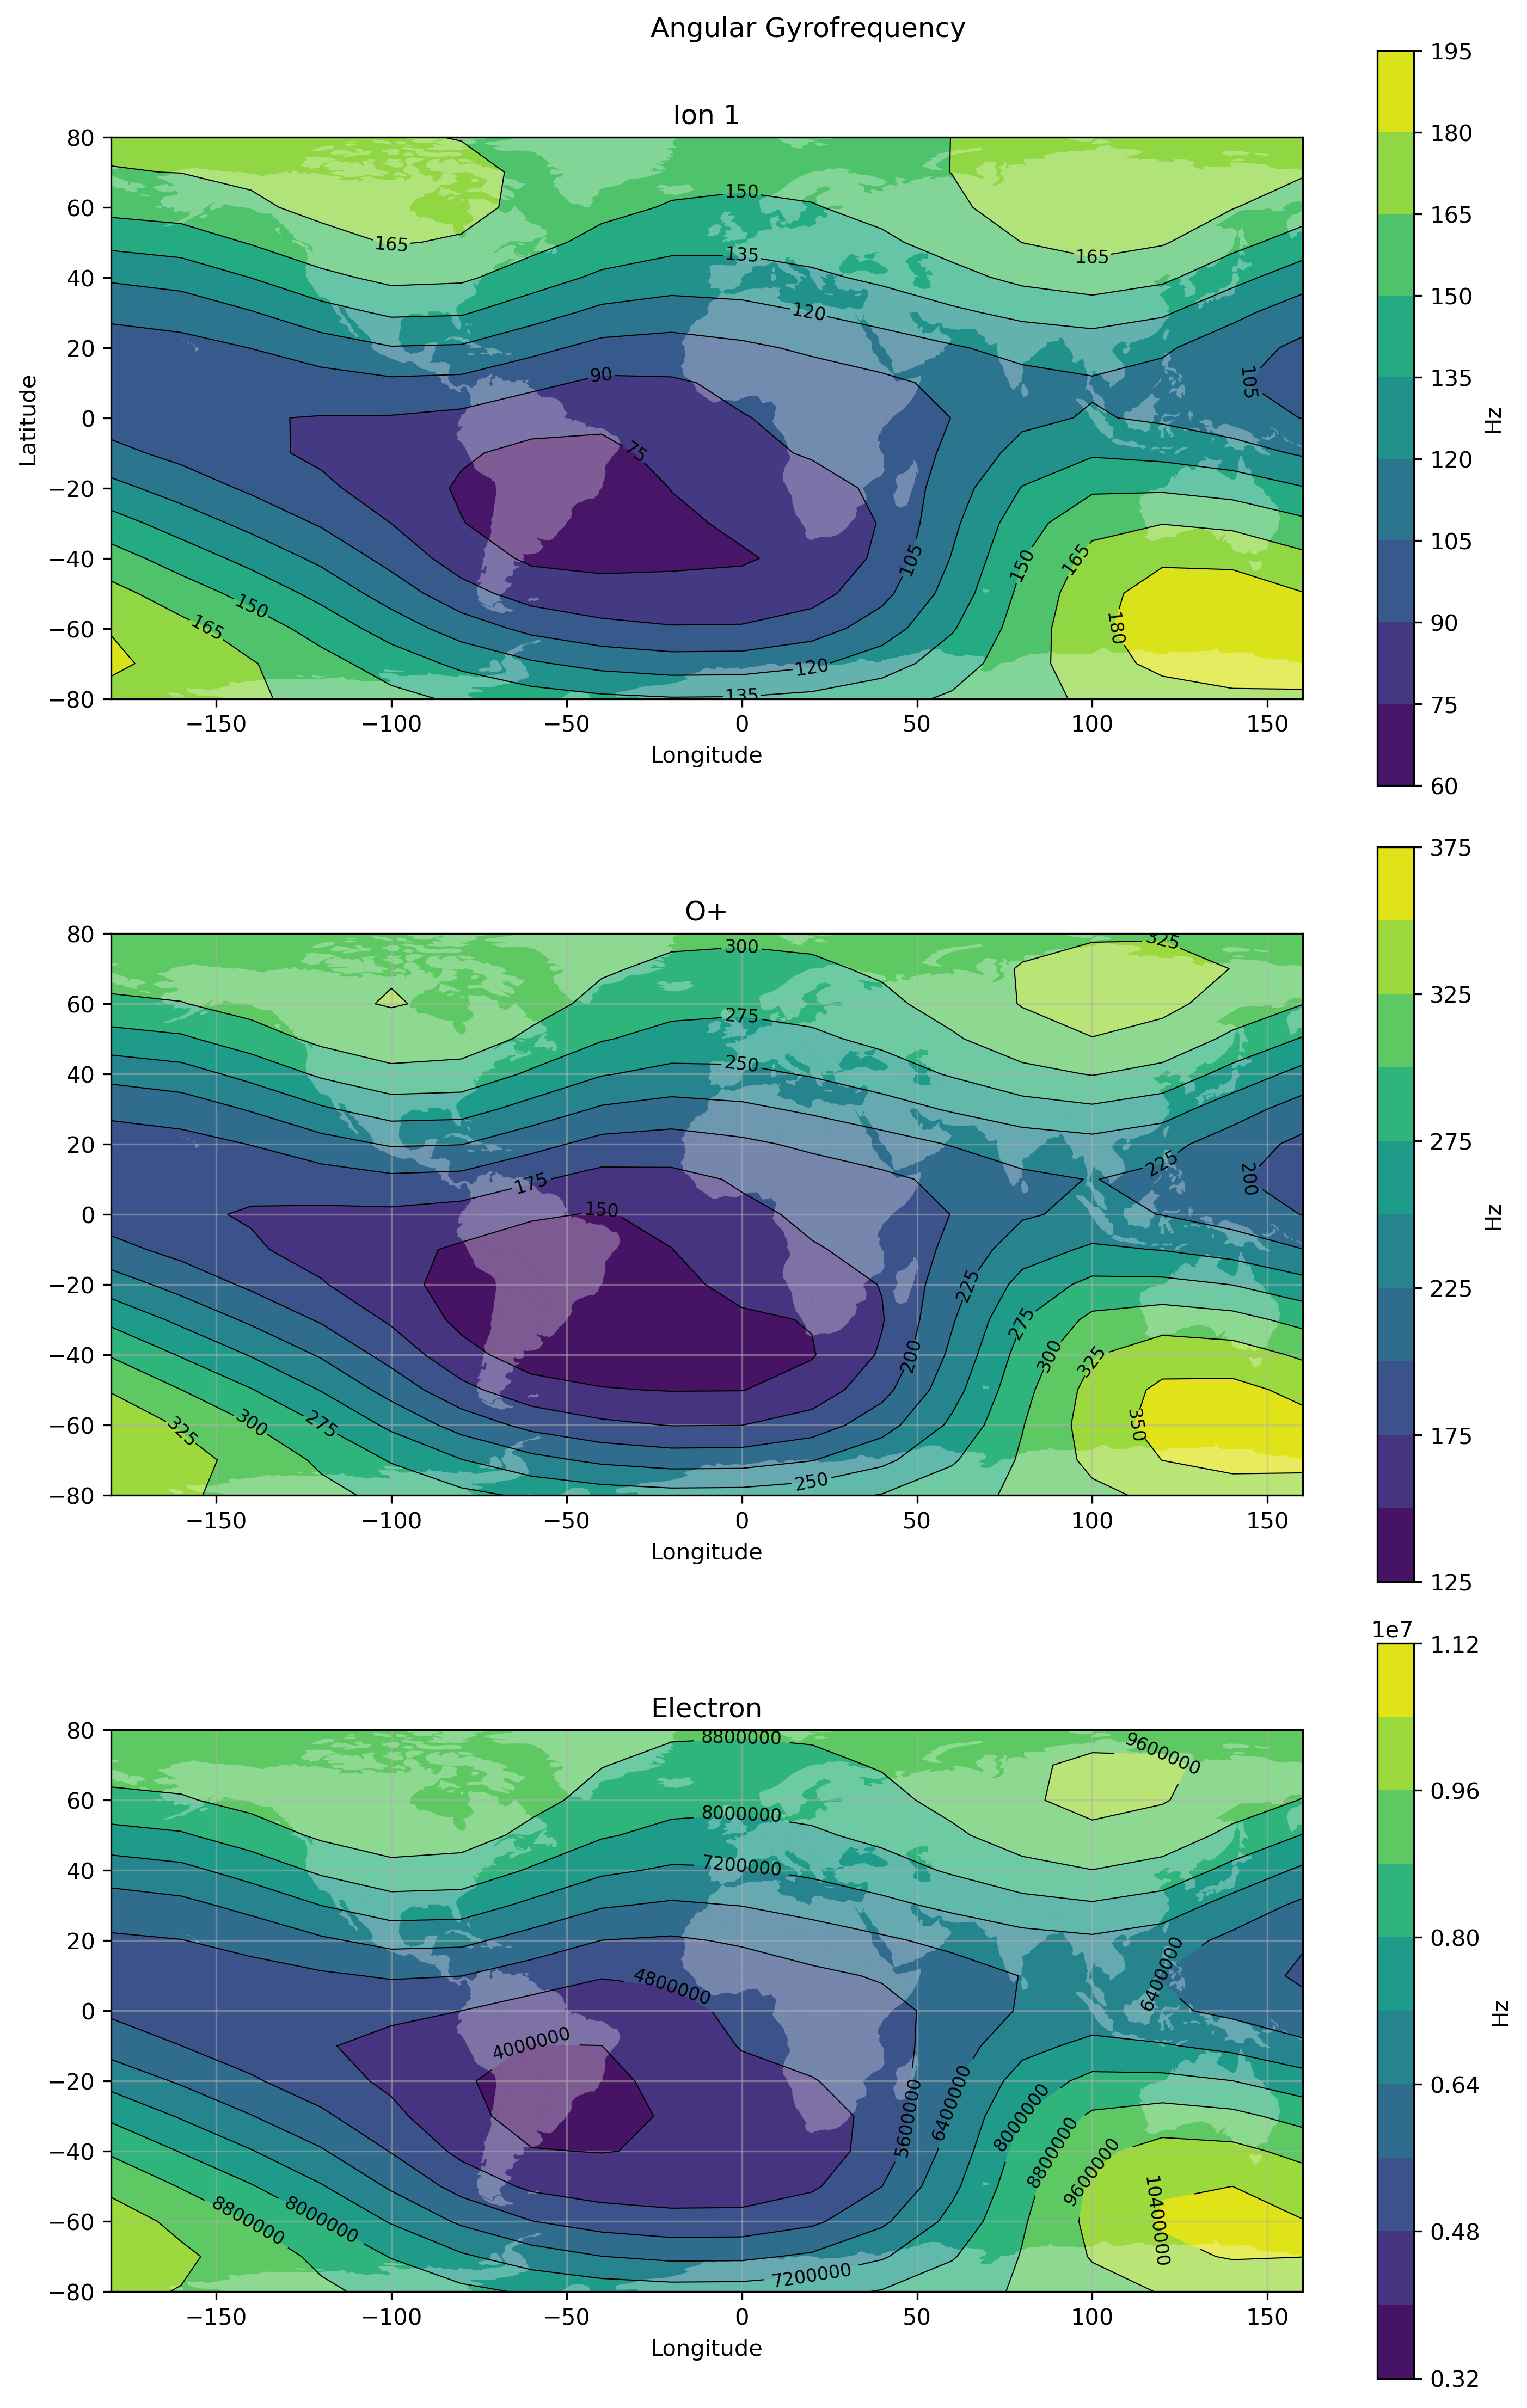

In [89]:
sizefig = (10,15)

fig,ax = plt.subplots(3,1,figsize = sizefig, dpi = 300,layout = 'tight')
fig.suptitle("Angular Gyrofrequency")

Xi,Yi,values = prepplot_2dgrid(calcvaluesdf['wi1'],h,"'Ion 1'")

cntr1 = ax[0].contourf(Xi,Yi,values,levels=10)
contour1 = ax[0].contour(Xi,Yi,values,levels=10,colors='black', linewidths=0.5)
plt.clabel(contour1, inline = True, fontsize=8)

ax[0].set_title("Ion 1")
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
cbar1 = fig.colorbar(cntr1, ax = ax[0], label = "Hz")
countries.plot(ax = ax[0], color = "white",figsize=sizefig, alpha=0.3)
ax[0].set_xlim([-180, 160])
ax[0].set_ylim([-80, 80])


X2,Y2,values2 = prepplot_2dgrid(calcvaluesdf['wi2'], h,"'O+'")

cntr2 = ax[1].contourf(X2, Y2, values2, levels = 10)
contour2 = ax[1].contour(X2, Y2, values2, levels = 10,colors='black', linewidths=0.5)
cbar2 = fig.colorbar(cntr2,ax=ax[1],label="Hz")

ax[1].clabel(contour2, inline = True, fontsize=8)
#countries["geometry"].boundary.plot(ax = ax[1], color = "yellow",figsize=sizefig, linewidths=0.3)
countries.plot(ax = ax[1], color = "white",figsize=sizefig, alpha=0.3)

ax[1].set_xlim([-180, 160])
ax[1].set_ylim([-80, 80])
ax[1].set_title('O+')
ax[1].set_xlabel("Longitude")
ax[1].grid(visible = True, alpha=0.5)


X3,Y3,values3 = prepplot_2dgrid(calcvaluesdf['we'],h,"'Electron'")

cntr3 = ax[2].contourf(X3,Y3,values3,levels = 10)
contour3 = ax[2].contour(X3,Y3,values3,levels=10,colors='black', linewidths=0.5)
cbar3 = fig.colorbar(cntr3,ax=ax[2],label="Hz")

countries.plot(ax = ax[2], color = "white",figsize=sizefig, alpha=0.3)
plt.clabel(contour3, inline = True, fontsize=8)

ax[2].set_xlim([-180, 160])
ax[2].set_ylim([-80, 80])
ax[2].set_title('Electron')
ax[2].set_xlabel("Longitude")
ax[2].grid(visible = True, alpha=0.5)

#countries.head()
name_saida = 'print'
fig.savefig("plot_Angular Gyrofrequency" + name_saida + '.jpg', dpi = 600, transparent=True)

#ax[1][0] = prepplot_2dgrid(calcvaluesdf['fen'],h,"Electron colission frequency")
#ax[1][1] = prepplot_2dgrid(calcvaluesdf['fin1'],h,"Ion1 colission frequency")
#plot_2dgrid(calcvaluesdf['fin2'],h,"Ion O colission frequency")

#### Collision Frequency

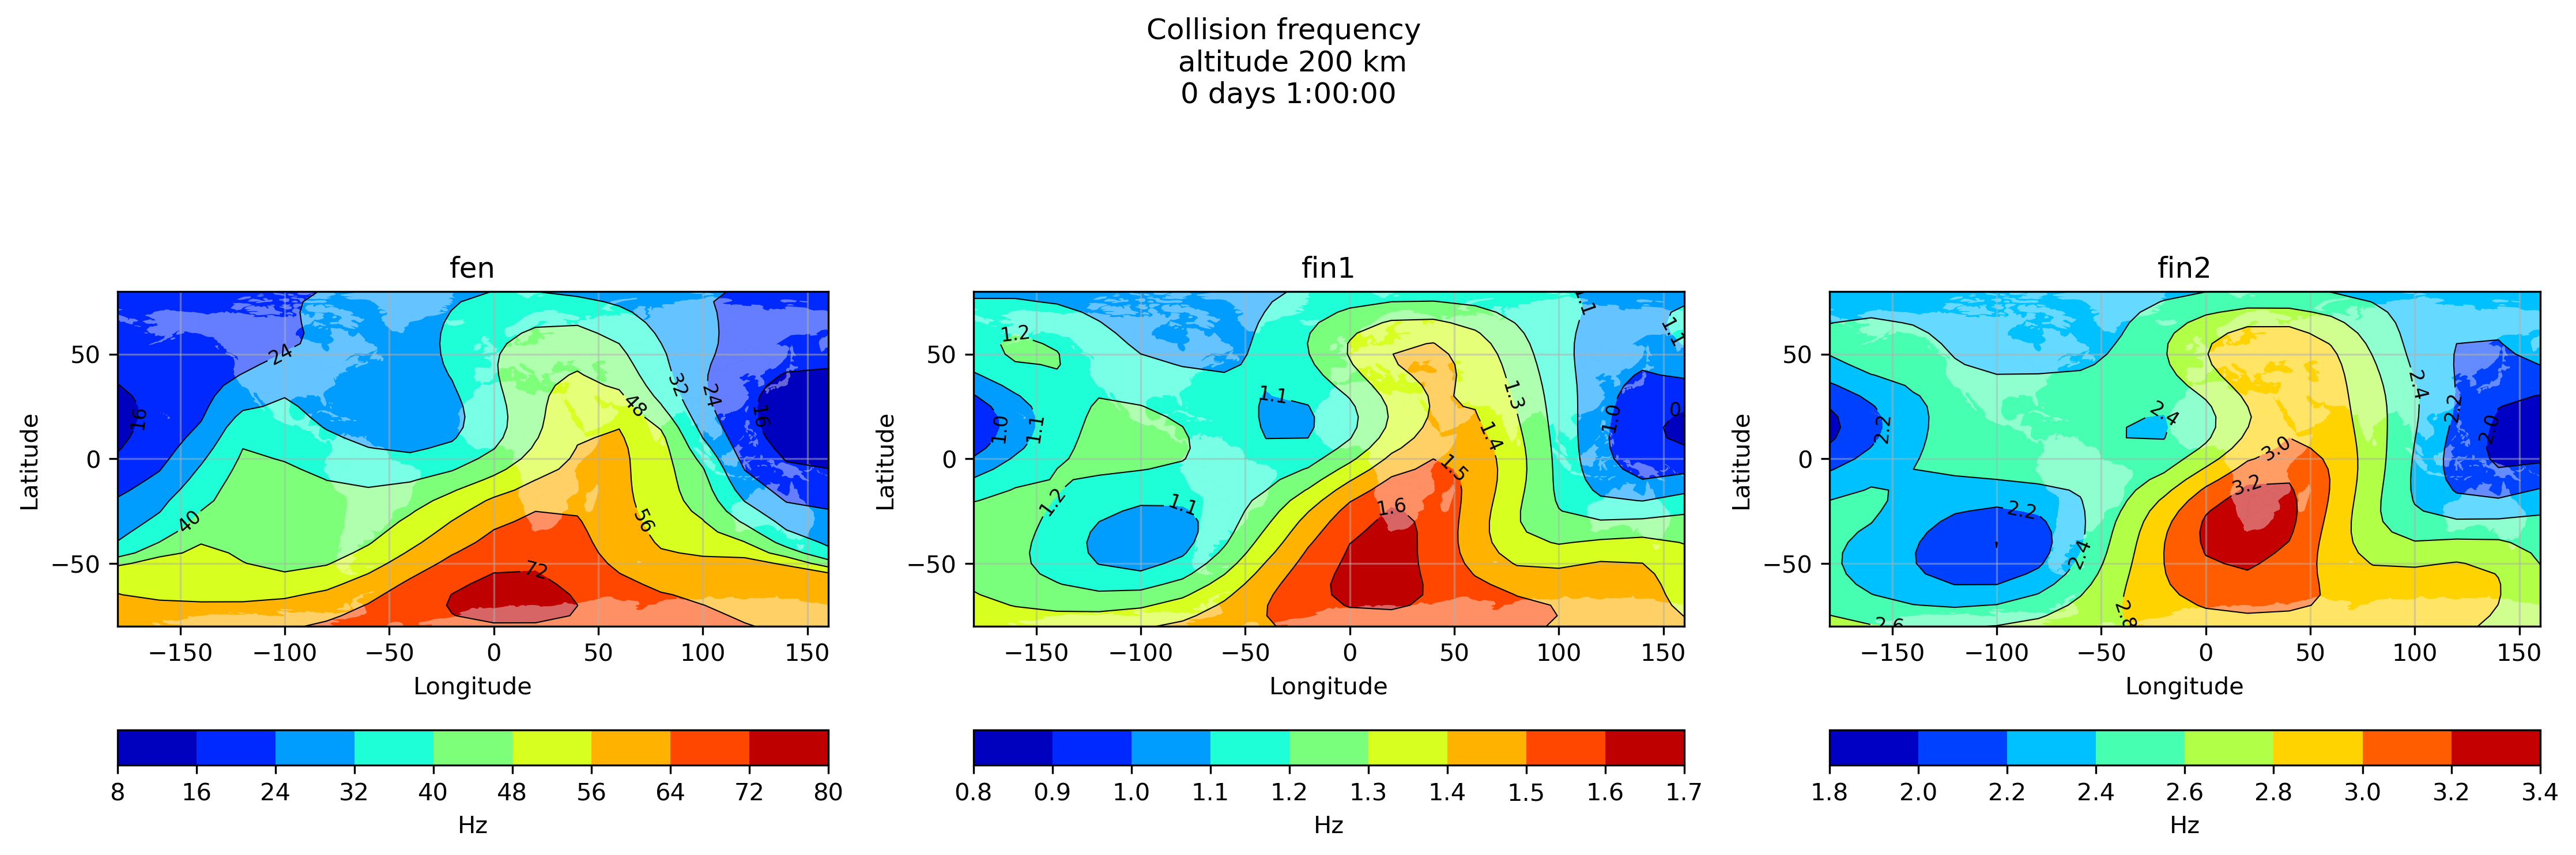

In [91]:
countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

fig,ax = plt.subplots(1,3,figsize = (15,5),dpi=300,layout = 'tight' )
fig.suptitle("Collision frequency \n altitude " + str(h) + ' km\n' 
             + str(time))

columns = freqc.result.columns.to_list()
titles = ['Electron Colision frequency',
    "Ion 1 - neutrals Colision frequency",
          'Ion O+ Colision frequency']

for i in range(3):
    X,Y = prepplot_create2Dmeshgrid(freqc.result[columns[i]].dropna(),h)
    valfreq = prepplot_valueto2Dgrid(freqc.result[columns[i]].dropna(),h)
    
    cntr = ax[i].contourf(X,Y,valfreq,cmap='jet')
    contour = ax[i].contour(X,Y,valfreq,colors='black', linewidths=0.5)

    countries.plot(ax = ax[i], color = "white",figsize=sizefig, alpha = 0.4)
    plt.clabel(contour, inline = True, fontsize = 8)
    
    ax[i].set_title(columns[i])
    ax[i].set_xlim([-180, 160])
    ax[i].set_ylim([-80, 80])
    #ax[i].axis('equal')
    ax[i].grid(visible = True, alpha = 0.5)
    ax[i].set_xlabel("Longitude")
    ax[i].set_ylabel("Latitude")
    cbar = fig.colorbar(cntr,ax = ax[i],location = 'bottom')
    cbar.set_label("Hz")


plt.savefig("frequenciasdecolisao.jpg",dpi=600)

In [92]:
calcvaluesdf['wi1']

ht     lat    lon  
100.0  -80.0  0.0      184.686988
              20.0     180.876687
              40.0     175.437217
              60.0     168.857966
              80.0     161.732656
                          ...    
480.0   80.0  260.0    148.802251
              280.0    150.027639
              300.0    150.354847
              320.0    149.937420
              340.0    149.226893
Name: wi1, Length: 6120, dtype: float64

#### Densidade de Elétrons

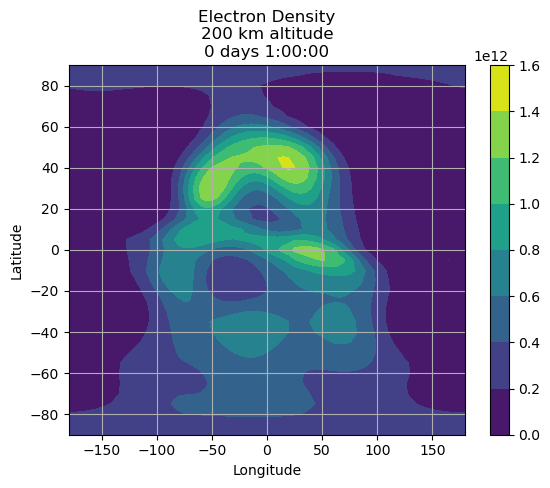

<module 'matplotlib.pyplot' from 'C:\\Users\\tedea\\Anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [94]:
plot_2dgrid(iriteste.iridata.data["Ne"].loc[time],h,"Electron Density\n"+str(h)+" km altitude\n" + time)

#### Conductivity Images

In [96]:
def plot_2dgrid(values,h,title=" "):
    values_plot = values.loc[h].reset_index() #leaving the multindex to use normal indexing
    countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

    X,Y = np.meshgrid(values_plot['lon'].unique() - 180,values_plot['lat'].unique())

    value2dformat = pd.DataFrame([])
    for i in values_plot['lon'].unique():
        value2dformat[i] = values.loc[h,:,i]

    fig, ax = plt.subplots()
    cntr = ax.contourf(X,Y,value2dformat)
    contour = ax.contour(X,Y,value2dformat,colors='black', linewidths=0.5)
    ax.clabel(contour, inline = True, fontsize = 8)

    countries.plot(ax=ax,color = "white",figsize=sizefig, alpha = 0.4)
    
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim([-180, 180])
    ax.set_ylim([-80,80])
    ax.grid(visible = True, alpha = 0.5)
    
    fig.colorbar(cntr, ax=ax, label='conductivity',location = 'bottom')

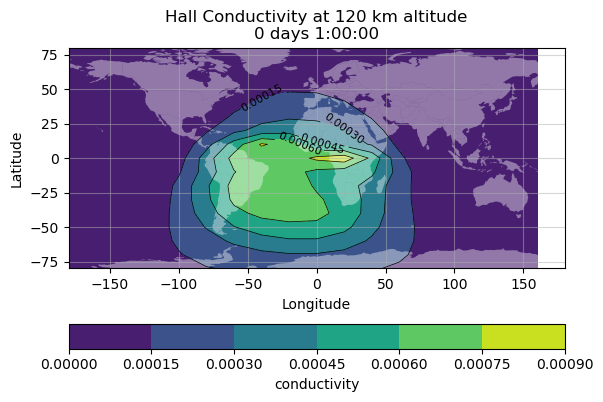

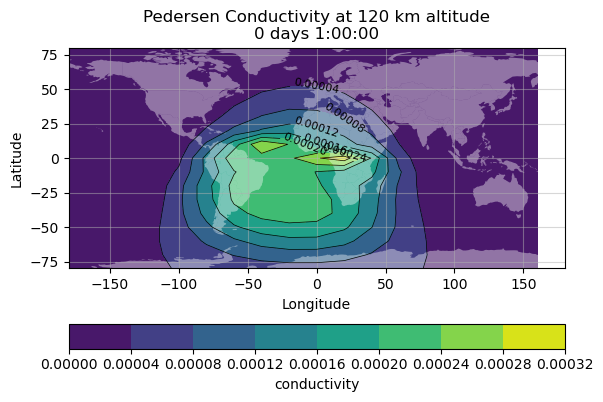

In [97]:
h = 120

plot_2dgrid(testehall.dropna(),h,'Hall Conductivity at '+ str(h) + " km altitude\n" +time)
plot_2dgrid(testepedersen.dropna(),h,'Pedersen Conductivity at '+str(h)+" km altitude\n"+time)

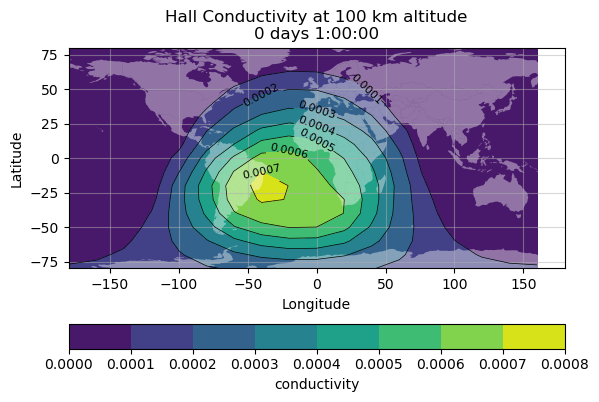

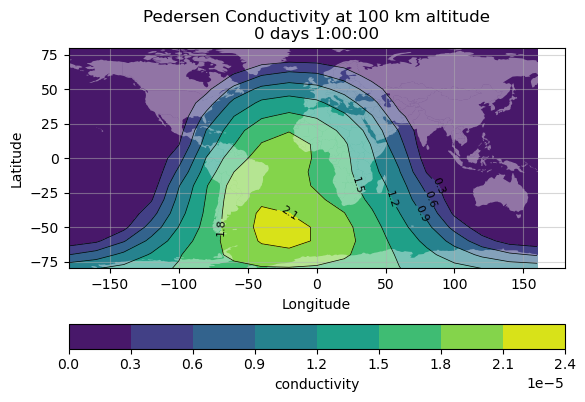

In [98]:
h = 100
plot_2dgrid(conductivity.CondH.dropna(),h,'Hall Conductivity at '+str(h)+" km altitude\n"+time)
plot_2dgrid(conductivity.CondP.dropna(),h,'Pedersen Conductivity at '+str(h)+" km altitude\n"+time)

In [99]:
def prepplot_2dgrid_simplified(values,h):    
    X,Y = prepplot_create2Dmeshgrid(values,h)
    value2dformat = prepplot_valueto2Dgrid(values,h)
        
    return X,Y,value2dformat

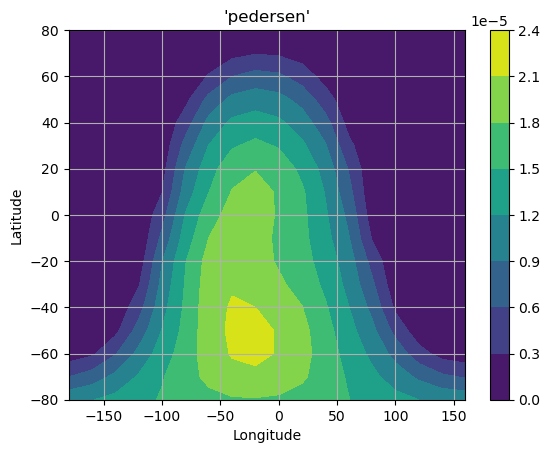

<module 'matplotlib.pyplot' from 'C:\\Users\\tedea\\Anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [100]:
def plot_2dgrid(values,h,title=" "):
    values_plot = values.loc[h].reset_index() #leaving the multindex to use normal indexing
    
    X,Y,value2dformat= prepplot_2dgrid_simplified(values,h)
        
    plt.contourf(X,Y,value2dformat)
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid()
    plt.colorbar()   
    
    plt.show()
    return plt
    
plot_2dgrid(conductivity.CondP.dropna(),h,"'pedersen'")

### Perfis

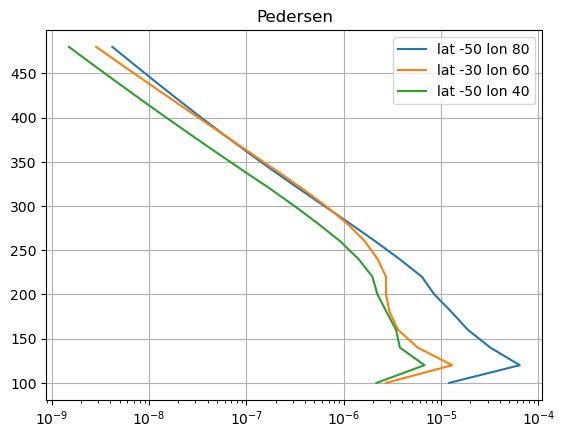

In [102]:
#plotando perfis 
plt.title("Pedersen")
plt.semilogx(testepedersen.loc[:,-50,80],testehall.index.get_level_values('ht').unique(),label='lat -50 lon 80')
plt.plot(testepedersen.loc[:,-30,60],testehall.index.get_level_values('ht').unique(),label='lat -30 lon 60')
plt.plot(testepedersen.loc[:,-50,40],testehall.index.get_level_values('ht').unique(),label='lat -50 lon 40')
plt.grid()
plt.legend()

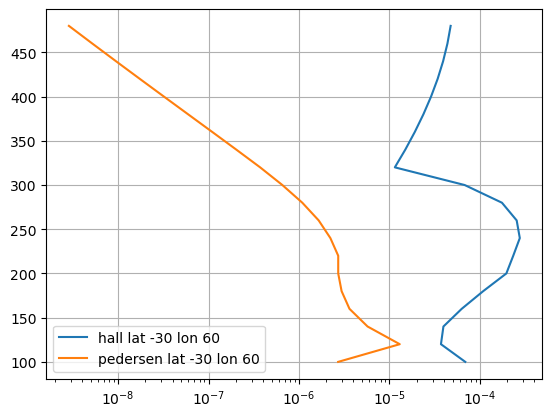

In [103]:
plt.plot(testehall.loc[:,-30,60],testehall.loc[:,:,:].index.get_level_values('ht').unique(),label = 'hall lat -30 lon 60')
plt.semilogx(testepedersen.loc[:,-30,60],testehall.index.get_level_values('ht').unique(),label='pedersen lat -30 lon 60')
plt.grid()
plt.legend()

In [104]:
testepedersen.loc[:,-50,80]

ht
100.0    1.210008e-05
120.0    6.429266e-05
140.0    3.189497e-05
160.0    1.882522e-05
180.0    1.282726e-05
200.0    8.519276e-06
220.0    6.347263e-06
240.0    3.742477e-06
260.0    2.116246e-06
280.0    1.164258e-06
300.0    6.315648e-07
320.0    3.430404e-07
340.0    1.886170e-07
360.0    1.053689e-07
380.0    5.973993e-08
400.0    3.437224e-08
420.0    2.003629e-08
440.0    1.181531e-08
460.0    7.037429e-09
480.0    4.195660e-09
dtype: float64

In [105]:
testehall.loc[:300,:,:].index.get_level_values('lat').unique()[:]

Index([-80.0, -70.0, -60.0, -50.0, -40.0, -30.0, -20.0, -10.0,   0.0,  10.0,
        20.0,  30.0,  40.0,  50.0,  60.0,  70.0,  80.0],
      dtype='float32', name='lat')

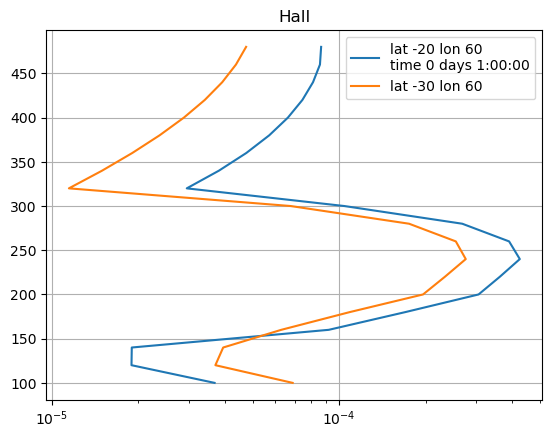

In [255]:
plt.title('Hall')
plt.semilogx(testehall.loc[:,-20,60],testehall.loc[:,:,:].index.get_level_values('ht').unique(),label = 'lat -20 lon 60 \ntime ' + str(time))
plt.plot(testehall.loc[:,-30,60],testehall.loc[:,:,:].index.get_level_values('ht').unique(),label = 'lat -30 lon 60')
#plt.plot(testehall.loc[:,-50,40],testehall.index.get_level_values('ht').unique(),label='lat -50 lon 40')
#plt.plot(testehall.loc[:,-50,100],testehall.index.get_level_values('ht').unique(),label='lat -50 lon 100')

#plt.plot(testehall.loc[:,-40,60],testehall.index.get_level_values('ht').unique(),label='lat -40 lon 60')
#plt.plot(testehall.loc[:,-40,80],testehall.index.get_level_values('ht').unique(),label='lat -40 lon 80')
plt.grid()
plt.legend()

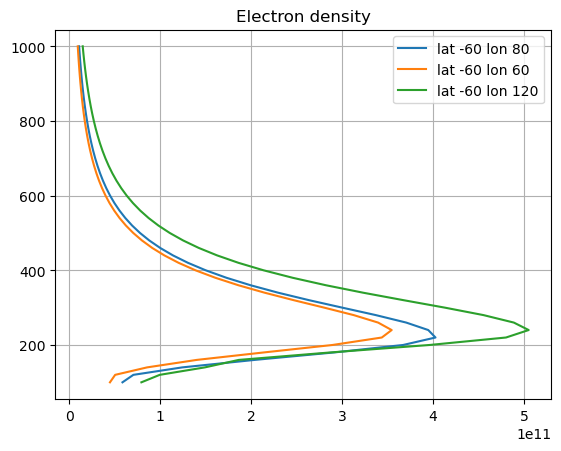

In [107]:
plt.title("Electron density")
plt.plot(ne.loc[:,-60,80],ne.index.get_level_values('ht').unique(),label='lat -60 lon 80')
plt.plot(ne.loc[:,-60,60],ne.index.get_level_values('ht').unique(),label='lat -60 lon 60')
plt.plot(ne.loc[:,-60,120],ne.index.get_level_values('ht').unique(),label='lat -60 lon 120')
plt.legend()
plt.grid()

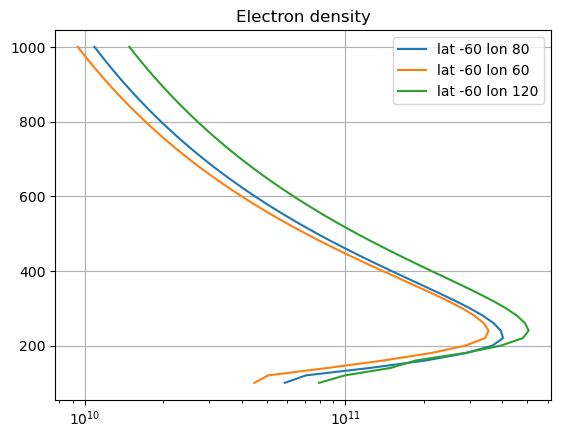

In [108]:
plt.title("Electron density")
plt.semilogx(ne.loc[:,-60,80],ne.index.get_level_values('ht').unique(),label='lat -60 lon 80')
plt.plot(ne.loc[:,-60,60],ne.index.get_level_values('ht').unique(),label='lat -60 lon 60')
plt.plot(ne.loc[:,-60,120],ne.index.get_level_values('ht').unique(),label='lat -60 lon 120')
plt.grid()
plt.legend()

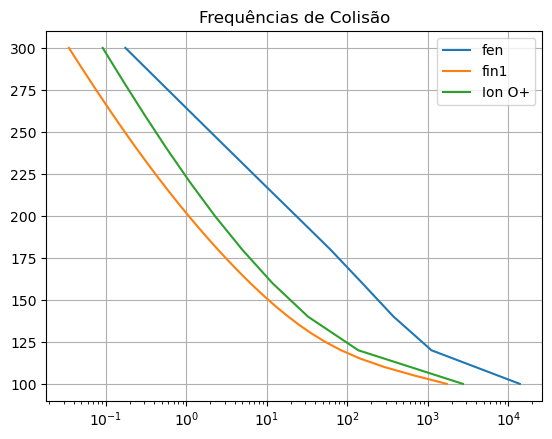

In [109]:
plt.semilogx(freqc.result['fen'].dropna().loc[:300,60,80],
         freqc.result['fen'].dropna().loc[:300,80,80].index.get_level_values('ht').unique(),
        label = "fen")

plt.semilogx(freqc.result['fin1'].dropna().loc[100:300,60,80],
         freqc.result['fin1'].dropna().loc[100:300,60,80].index.get_level_values('ht').unique(),
        label = "fin1")
plt.semilogx(freqc.result['fin2'].dropna().loc[:300,60,80],
         freqc.result['fin2'].dropna().loc[:300,60,80].index.get_level_values('ht').unique(),
        label = "Ion O+")
plt.title("Frequências de Colisão")
plt.legend()
plt.grid()

In [110]:
len(freqc.result['fin1'].dropna().loc[:300,60,80])

61

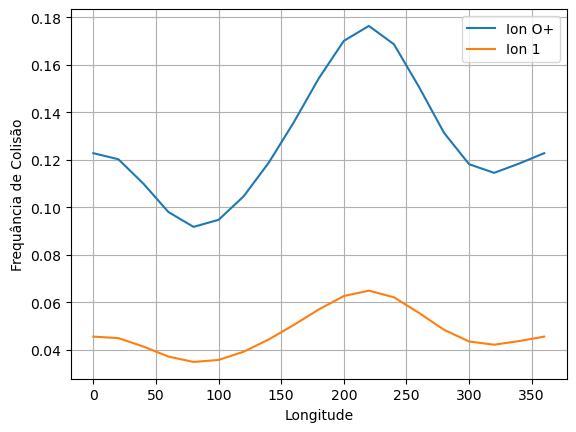

In [111]:
plt.plot(freqc.result['fin2'].dropna().loc[300,60,:].index.get_level_values('lon').unique(),
    freqc.result['fin2'].dropna().loc[300,60,:],         
        label = "Ion O+")
plt.plot(freqc.result['fin1'].dropna().loc[300,60,:].index.get_level_values('lon').unique(),
    freqc.result['fin1'].dropna().loc[300,60,:],         
        label = "Ion 1")
plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Frequância de Colisão")
plt.grid()

#### Perfil lat

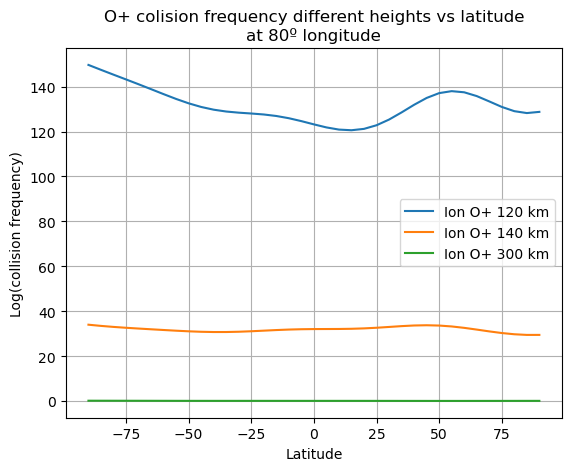

In [113]:
plt.plot(freqc.result['fin2'].dropna().loc[120,:,80].index.get_level_values('lat').unique(),
    freqc.result['fin2'].dropna().loc[120,:,80],         
        label = "Ion O+ 120 km")
plt.plot(freqc.result['fin2'].dropna().loc[140,:,80].index.get_level_values('lat').unique(),
    freqc.result['fin2'].dropna().loc[140,:,80],         
        label = "Ion O+ 140 km")
plt.plot(freqc.result['fin2'].dropna().loc[300,:,80].index.get_level_values('lat').unique(),
    freqc.result['fin2'].dropna().loc[300,:,80],         
        label = "Ion O+ 300 km")
plt.legend()
plt.title("O+ colision frequency different heights vs latitude\nat 80º longitude")

plt.xlabel("Latitude")
plt.ylabel("Log(collision frequency)")
plt.grid()

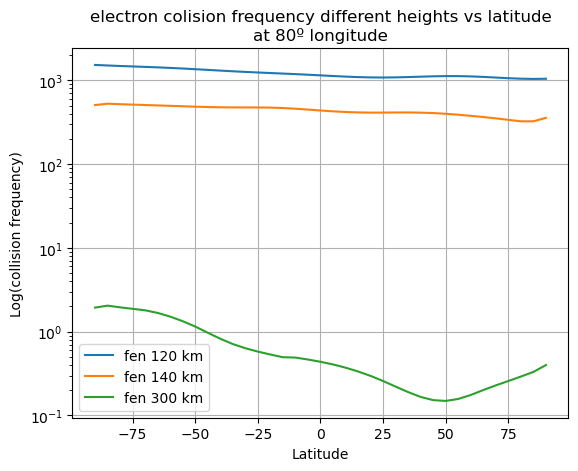

In [114]:
plt.semilogy(freqc.result['fen'].dropna().loc[120,:,80].index.get_level_values('lat').unique(),
    freqc.result['fen'].dropna().loc[120,:,80],         
        label = "fen 120 km")
plt.plot(freqc.result['fen'].dropna().loc[140,:,80].index.get_level_values('lat').unique(),
    freqc.result['fen'].dropna().loc[140,:,80],         
        label = "fen 140 km")
plt.plot(freqc.result['fen'].dropna().loc[300,:,80].index.get_level_values('lat').unique(),
    freqc.result['fen'].dropna().loc[300,:,80],         
        label = "fen 300 km")
plt.legend()
plt.title("electron colision frequency different heights vs latitude\nat 80º longitude")
plt.xlabel("Latitude")
plt.ylabel("Log(collision frequency)")
plt.grid()

In [115]:
lat1 = 60
lon1 = 80
a = np.trapz(testehall.loc[:400,lat1,lon1], testehall.loc[:400,:,:].index.get_level_values('ht').unique())

# Height Integrated Conductivity

In [117]:
#heightintegratedcond = pd.DataFrame([(lat1,lon1,a)],columns=['lat','lon','cond Hall [S]'])
#heightintegratedcond

#### Passar para função

In [119]:
import scipy.integrate as scp

In [120]:
testehall.loc[:,:,:].index.get_level_values('ht').unique().to_list()

[100.0,
 120.0,
 140.0,
 160.0,
 180.0,
 200.0,
 220.0,
 240.0,
 260.0,
 280.0,
 300.0,
 320.0,
 340.0,
 360.0,
 380.0,
 400.0,
 420.0,
 440.0,
 460.0,
 480.0]

In [121]:
#creating dataframe with values of height integrated conductivity in a matrix
a = [] #list to be filled with height intratade values. cada linha é numa latitude específica e coluna uma longitude
for lat in testehall.loc[:400,:,:].index.get_level_values('lat').unique().to_list():
    a.append( [(np.trapz(testehall.loc[:400,lat,lon],testehall.loc[:400,:,:].index.get_level_values('ht').unique())) for lon in testehall.loc[:400,:,:].index.get_level_values('lon').unique().to_list()])

heightintegratedcond = pd.DataFrame(a, index= testehall.loc[:400,:,:].index.get_level_values('lat').unique().to_list(),columns= testehall.loc[:400,:,:].index.get_level_values('lon').unique().to_list())

In [122]:
def calc_height_integrtated_conductivity(values,h=480):
    a = [] #list to be filled with height intratade values. cada linha é numa latitude específica e coluna uma longitude
    #h = 500
    for lat in values.loc[:h,:,:].index.get_level_values('lat').unique().to_list():
        a.append( [(np.trapz(values.loc[:h,lat,lon],values.loc[:h,:,:].index.get_level_values('ht').unique())) for lon in values.loc[:h,:,:].index.get_level_values('lon').unique().to_list()])
    
    heightintegratedcond = pd.DataFrame(a, index= values.loc[:h,:,:].index.get_level_values('lat').unique().to_list(),columns= values.loc[:h,:,:].index.get_level_values('lon').unique().to_list())
    return heightintegratedcond 

In [123]:
def calc_height_integrtated_conductivity2(values,h=480):
    a = [] #list to be filled with height intratade values. cada linha é numa latitude específica e coluna uma longitude
    #h = 500
    for lat in values.loc[:h,:,:].index.get_level_values('lat').unique().to_list():
        a.append( [(scp.trapz(values.loc[:h,lat,lon],values.loc[:h,:,:].index.get_level_values('ht').unique())) for lon in values.loc[:h,:,:].index.get_level_values('lon').unique().to_list()])
    
    heightintegratedcond = pd.DataFrame(a, index= values.loc[:h,:,:].index.get_level_values('lat').unique().to_list(),columns= values.loc[:h,:,:].index.get_level_values('lon').unique().to_list())
    return heightintegratedcond 

In [124]:
heightintegratedcond3 = calc_height_integrtated_conductivity2(conductivity.CondH.dropna(),h=480)
heightintegratedcond3

,0.0,20.0,40.0,60.0,80.0,100.0,120.0,140.0,160.0,180.0,200.0,220.0,240.0,260.0,280.0,300.0,320.0,340.0
-80.0,0.002184,0.001762,0.001857,0.002378,0.003072,0.002839,0.003448,0.003896,0.004098,0.004104,0.003779,0.002582,0.003084,0.002214,0.002650,0.001974,0.001849,0.002045
-70.0,0.001540,0.001709,0.001758,0.002342,0.003121,0.003987,0.004760,0.006190,0.006870,0.006931,0.006154,0.004948,0.004490,0.002729,0.001826,0.001696,0.001835,0.001967
-60.0,0.002888,0.001980,0.002376,0.002056,0.003343,0.005538,0.007762,0.009649,0.010943,0.011046,0.009462,0.006440,0.004459,0.003181,0.001897,0.002757,0.003195,0.003467
-50.0,0.005580,0.003073,0.001924,0.002743,0.004630,0.007834,0.011723,0.014428,0.015832,0.015946,0.013440,0.008999,0.005504,0.003954,0.003746,0.006253,0.008296,0.007828
-40.0,0.010692,0.005169,0.003041,0.003405,0.006880,0.011641,0.017845,0.020297,0.020774,0.020722,0.018489,0.012901,0.006989,0.005598,0.008342,0.014259,0.019160,0.017569
-30.0,0.020183,0.008774,0.005726,0.005831,0.009786,0.018317,0.027136,0.029484,0.030312,0.031194,0.030030,0.022951,0.016371,0.014092,0.019929,0.029797,0.034802,0.032925
-20.0,0.036985,0.019225,0.013466,0.011066,0.015274,0.028906,0.040702,0.049347,0.057419,0.060306,0.054262,0.041094,0.026782,0.027143,0.035743,0.050442,0.058298,0.054595
-10.0,0.071232,0.048735,0.028548,0.015904,0.018426,0.033644,0.051211,0.069168,0.081409,0.072418,0.057175,0.045447,0.040369,0.036828,0.043093,0.053149,0.092091,0.087925
0.0,0.104933,0.068751,0.030314,0.014204,0.016188,0.030739,0.050536,0.061858,0.066849,0.063529,0.058493,0.049070,0.036088,0.036659,0.054686,0.109953,0.090602,0.121085
10.0,0.100262,0.073376,0.030483,0.011552,0.013434,0.026989,0.039879,0.051084,0.053566,0.048982,0.041653,0.030765,0.021081,0.021086,0.036938,0.102641,0.183070,0.115078


In [125]:
#conductivity.CondH.dropna()

In [126]:
#print(heightintegratedcond3,'\n\n\n\n =========================== height out of function =======================\n',heightintegratedcond)

In [127]:
#testehall

In [128]:
# heightintegratedcond1 = heightintegratedcond
# for lon in testehall.loc[:400,:,:].index.get_level_values('lon').unique().to_list():
#     heightintegratedcond1  = heightintegratedcond1._append( pd.DataFrame([(lat,lon,np.trapz(testehall.loc[:400,lat,lon],
#                                                                                            testehall.loc[:400,:,:].index.get_level_values('ht').unique()))
#                                                                          for lat in testehall.loc[:400,:,:].index.get_level_values('lat').unique().to_list()]), ignore_index=True)

In [129]:
#testehall.loc[:400,:,:].index.get_level_values('lat').unique().to_list()

In [130]:
# heightintegratedcond2 = heightintegratedcond
# for lon in testehall.loc[:400,:,:].index.get_level_values('lon').unique().to_list():
#     heightintegratedcond2 = heightintegratedcond2._append(
#         pd.DataFrame([(lat,lon,np.trapz(testehall.loc[:400,lat,lon],testehall.loc[:400,:,:].index.get_level_values('ht').unique())) for lat in testehall.loc[:400,:,:].index.get_level_values('lat').unique().to_list()]), ignore_index=True)
#     heightintegratedcond2

In [131]:
#values_plot

In [132]:
values_plot = heightintegratedcond3
X,Y = np.meshgrid(values_plot.columns - 180,values_plot.index)

In [133]:
#print(X,"\n\n\n",Y)

In [134]:
#print(X,"\n\n\n",Y)

In [135]:
def plot_2dgrid_hintegrated(value2dformat,X,Y,h,title=" "):
    plt.contourf(X,Y,value2dformat)
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid()
    plt.colorbar()   
    
    plt.show()
    return plt    

def plot_2dgrid_hintegrated2(value2dformat,X,Y,h,title=" ",sizefig=(10,15)):
    countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    
    fig, ax = plt.subplots()
    cntr = ax.contourf(X,Y,value2dformat,cmap = 'jet')
    contour = ax.contour(X,Y,value2dformat,colors = 'black', linewidths=0.5)
    ax.clabel(contour, inline = True, fontsize = 8)

    countries.plot(ax=ax,color = "white",figsize=sizefig, alpha = 0.2)
    
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim([-180, 160])
    ax.set_ylim([-80,80])
    ax.grid(visible = True, alpha = 0.5)
    
    fig.colorbar(cntr, ax = ax, label = 'Conductivity [S]',location = 'bottom')
    fig.savefig("plot_" + title +'.jpg', dpi = 500, transparent=True)
    plt.show()

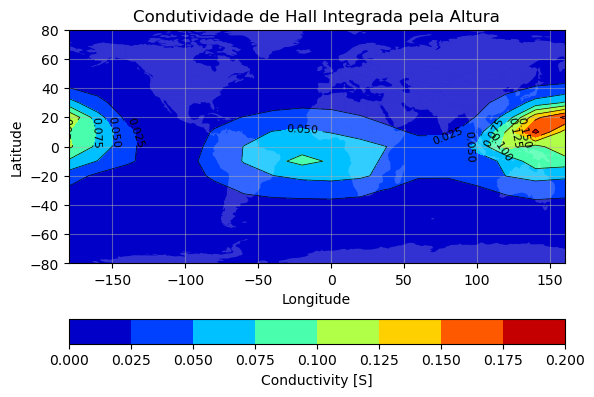

In [136]:
h = 120
plot_2dgrid_hintegrated2(values_plot,X,Y,h,title="Condutividade de Hall Integrada pela Altura")

In [137]:
testehall.loc[:400,lat,:]

ht     lat   lon  
100.0  80.0  0.0      0.000005
             20.0     0.000005
             40.0     0.000005
             60.0     0.000005
             80.0     0.000005
                        ...   
400.0  80.0  260.0    0.000013
             280.0    0.000015
             300.0    0.000016
             320.0    0.000018
             340.0    0.000019
Length: 288, dtype: float64

In [138]:
conductivity.CondH.dropna().to_csv("CondH_6h" + ".csv",sep=",",header=True)

In [139]:
conductivity.CondP.dropna().to_csv("CondP_6h" + ".csv",sep=",",header=True)

In [140]:
heightintegratedcondP3 = calc_height_integrtated_conductivity2(conductivity.CondP.dropna(),h=500)
values_plot_pedersen = heightintegratedcondP3
Xp,Yp = np.meshgrid(values_plot_pedersen.columns - 180,values_plot.index)

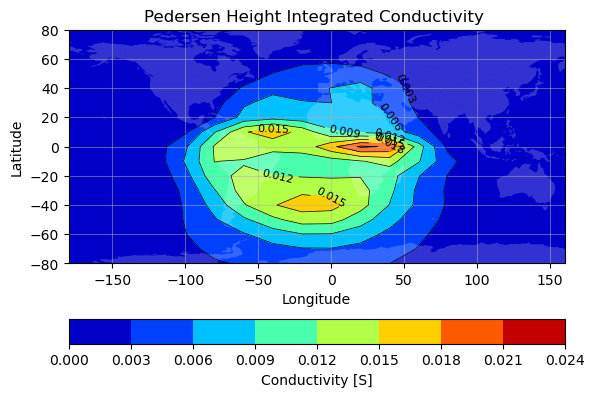

In [141]:
plot_2dgrid_hintegrated2(values_plot_pedersen,Xp,Yp,h,title="Pedersen Height Integrated Conductivity ")